In [1]:
import os
import json
import copy
import random
import warnings
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from joblib import dump, load

import textwrap
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

import numpy as np
import pandas as pd

from IPython.display import display
from IPython import get_ipython

# Import CPU PCA BEFORE enabling cuml.accel
from sklearn.decomposition import PCA as CPU_PCA

# Optional GPU acceleration for supported sklearn estimators
USE_GPU_ACCEL = True
GPU_ACCEL_ACTIVE = False
CUML_ACCEL_AVAILABLE = False

if USE_GPU_ACCEL:
    try:
        ip = get_ipython()

        if ip is not None:
            # In notebooks, enable before importing sklearn estimators you want accelerated
            ip.run_line_magic("load_ext", "cuml.accel")
            import cuml.accel
        else:
            import cuml
            cuml.accel.install(log_level="warn")
            import cuml.accel

        GPU_ACCEL_ACTIVE = cuml.accel.enabled()
        CUML_ACCEL_AVAILABLE = True
        print(f"[GPU] cuML accel enabled: {GPU_ACCEL_ACTIVE}")
    except Exception as e:
        GPU_ACCEL_ACTIVE = False
        CUML_ACCEL_AVAILABLE = False
        print(f"[WARN] cuML accel not enabled, falling back to CPU: {e}")

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.metrics import r2_score
from sklearn.model_selection import GroupKFold, KFold
from sklearn.preprocessing import StandardScaler

if USE_GPU_ACCEL and CUML_ACCEL_AVAILABLE:
    import cuml.accel
    print("cuml.accel enabled():", cuml.accel.enabled())
    print("CPU_PCA proxy:", cuml.accel.is_proxy(CPU_PCA))
    print("Ridge proxy:", cuml.accel.is_proxy(Ridge))
    print("ElasticNet proxy:", cuml.accel.is_proxy(ElasticNet))

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

# Seeds 
BASE_SEED = 19537
ALL_SEEDS = [19537, 1584678, 17052356]

SEED = BASE_SEED
random.seed(SEED)
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

def set_seeds(seed: int) -> None:
    global SEED, RNG
    SEED = int(seed)
    random.seed(SEED)
    np.random.seed(SEED)
    RNG = np.random.default_rng(SEED)

warnings.filterwarnings("ignore", category=UserWarning)

# Paths 
ARTIFACTS = Path("artifacts")
IN_CLEAN  = ARTIFACTS / "cleaned"  / "notebook 2"
IN_T2     = ARTIFACTS / "aligned"  / "notebook 1" / "track2_nonintersection"
IN_META   = ARTIFACTS / "metadata"

NOTEBOOK_SUBDIR = "notebook 4"
OUT_REPORTS = ARTIFACTS / "reports"  / NOTEBOOK_SUBDIR
OUT_META    = ARTIFACTS / "metadata" / NOTEBOOK_SUBDIR
OUT_CACHE   = ARTIFACTS / "cache"    / NOTEBOOK_SUBDIR

for d in [OUT_REPORTS, OUT_META, OUT_CACHE]:
    d.mkdir(parents=True, exist_ok=True)

# Load backbone lock 
LOCK_PATH = IN_META / "proteomics_backbone_lock.json"
if not LOCK_PATH.exists():
    raise FileNotFoundError(
        f"proteomics_backbone_lock.json not found at {LOCK_PATH}. "
        "Run the lock cell at the end of Notebook 3b first."
    )
with LOCK_PATH.open("r") as f:
    backbone_lock = json.load(f)

PRIMARY_ARM   = backbone_lock["track1_primary_arm"]
SECONDARY_ARM = backbone_lock["track1_secondary_arm"]
TRACK2_ARM    = backbone_lock["track2_stress_test_arm"]

print("Backbone lock loaded.")
print(f"  Primary arm  : {PRIMARY_ARM}")
print(f"  Secondary arm: {SECONDARY_ARM}")
print(f"  Track 2 arm  : {TRACK2_ARM}")
print(f"  Seeds to run : {ALL_SEEDS}")

# Exact top-10 ranked configurations from Notebook 3b
TOP10_CONFIGS = [
    {"rank": 1,  "arm": "prot_combined_union",      "model": "elasticnet", "feature_set": "rna"},
    {"rank": 2,  "arm": "prot_rppa_ccle",           "model": "elasticnet", "feature_set": "rna+prot"},
    {"rank": 3,  "arm": "prot_rppa_ccle",           "model": "elasticnet", "feature_set": "rna"},
    {"rank": 4,  "arm": "prot_combined_union",      "model": "elasticnet", "feature_set": "rna+mut"},
    {"rank": 5,  "arm": "prot_combined_union",      "model": "elasticnet", "feature_set": "rna+mut+prot"},
    {"rank": 6,  "arm": "prot_combined_union",      "model": "elasticnet", "feature_set": "rna+prot"},
    {"rank": 7,  "arm": "prot_procan_depmapSanger", "model": "elasticnet", "feature_set": "rna+mut+prot"},
    {"rank": 8,  "arm": "prot_rppa_ccle",           "model": "elasticnet", "feature_set": "rna+mut"},
    {"rank": 9,  "arm": "prot_rppa_ccle",           "model": "elasticnet", "feature_set": "rna+mut+prot"},
    {"rank": 10, "arm": "prot_procan_depmapSanger", "model": "elasticnet", "feature_set": "prot"},
]

# Arms now come from the actual top-10 rows, not just the lock file
ACTIVE_ARMS = sorted({cfg["arm"] for cfg in TOP10_CONFIGS})

CONFIGS_BY_ARM = {
    arm: [cfg for cfg in TOP10_CONFIGS if cfg["arm"] == arm]
    for arm in ACTIVE_ARMS
}

# Separate CNV-focused configs.
# These are not part of the proteomics top-10 lock.
# They are only for testing whether explicit CNV imputation is useful.
CNV_TEST_CONFIGS = (
    [{"rank": 1000, "arm": arm, "model": "elasticnet", "feature_set": "cnv"} for arm in ACTIVE_ARMS] +
    [{"rank": 1001, "arm": arm, "model": "elasticnet", "feature_set": "rna+cnv"} for arm in ACTIVE_ARMS] +
    [{"rank": 1002, "arm": arm, "model": "elasticnet", "feature_set": "cnv+mut"} for arm in ACTIVE_ARMS] +
    [{"rank": 1003, "arm": arm, "model": "elasticnet", "feature_set": "rna+cnv+mut"} for arm in ACTIVE_ARMS] +
    [{"rank": 1004, "arm": arm, "model": "elasticnet", "feature_set": "cnv+prot"} for arm in ACTIVE_ARMS] +
    [{"rank": 1005, "arm": arm, "model": "elasticnet", "feature_set": "rna+cnv+prot"} for arm in ACTIVE_ARMS] +
    [{"rank": 1006, "arm": arm, "model": "elasticnet", "feature_set": "rna+cnv+mut+prot"} for arm in ACTIVE_ARMS]
)

CNV_CONFIGS_BY_ARM = {
    arm: [cfg for cfg in CNV_TEST_CONFIGS if cfg["arm"] == arm]
    for arm in ACTIVE_ARMS
}

EXPECTED_CNV_CONFIG_KEYS = {
    (int(cfg["rank"]), str(cfg["arm"]), str(cfg["model"]).lower(), str(cfg["feature_set"]))
    for cfg in CNV_TEST_CONFIGS
}

EXPECTED_CNV_CONFIG_KEYS_BY_ARM = {
    arm: {
        (int(cfg["rank"]), str(cfg["arm"]), str(cfg["model"]).lower(), str(cfg["feature_set"]))
        for cfg in cfgs
    }
    for arm, cfgs in CNV_CONFIGS_BY_ARM.items()
}

print("\nTop-10 ranked configs loaded.")
display(pd.DataFrame(TOP10_CONFIGS))
print("Active arms from top-10 configs:", ACTIVE_ARMS)

# Bake-off settings 
N_DRUGS_BAKEOFF    = 100
MIN_CELLS_PER_DRUG = 80
N_SPLITS_DESIRED   = 10
RIDGE_ALPHA        = 1.0
EN_ALPHA           = 0.05
EN_L1_RATIO        = 0.2
PCA_COMPONENTS     = 100
KNN_NEIGHBORS      = 5
PRIMARY_TARGET     = "auc"

CACHE_VERSION = "v1"
CACHE_TAG = f"{CACHE_VERSION}__pca{PCA_COMPONENTS}__knn{KNN_NEIGHBORS}"

AUXPROT_LOCK_FILENAME = "imputer_choice.json"
CNV_LOCK_FILENAME = "cnv_imputer_choice.json"

[GPU] cuML accel enabled: True
cuml.accel enabled(): True
CPU_PCA proxy: False
Ridge proxy: True
ElasticNet proxy: True
Backbone lock loaded.
  Primary arm  : prot_procan_depmapSanger
  Secondary arm: prot_ms_ccle_gygi
  Track 2 arm  : prot_combined_union
  Seeds to run : [19537, 1584678, 17052356]

Top-10 ranked configs loaded.


,rank,arm,model,feature_set
0,1,prot_combined_union,elasticnet,rna
1,2,prot_rppa_ccle,elasticnet,rna+prot
2,3,prot_rppa_ccle,elasticnet,rna
3,4,prot_combined_union,elasticnet,rna+mut
4,5,prot_combined_union,elasticnet,rna+mut+prot
5,6,prot_combined_union,elasticnet,rna+prot
6,7,prot_procan_depmapSanger,elasticnet,rna+mut+prot
7,8,prot_rppa_ccle,elasticnet,rna+mut
8,9,prot_rppa_ccle,elasticnet,rna+mut+prot
9,10,prot_procan_depmapSanger,elasticnet,prot


Active arms from top-10 configs: ['prot_combined_union', 'prot_procan_depmapSanger', 'prot_rppa_ccle']


In [ ]:
#  Helpers 
def read_parquet_strict(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing parquet: {path}")
    return pd.read_parquet(path)

def normalise_str_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = df.index.astype(str)
    return df

def spearman_corr(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2:
        return np.nan
    rt = pd.Series(y_true).rank(method="average").to_numpy(dtype=float)
    rp = pd.Series(y_pred).rank(method="average").to_numpy(dtype=float)
    if np.std(rt) == 0 or np.std(rp) == 0:
        return np.nan
    return float(np.corrcoef(rt, rp)[0, 1])

def pick_group_column(cell_index: pd.DataFrame) -> str:
    for c in ["lineage_1", "primary_disease", "lineage", "lineage_2"]:
        if c in cell_index.columns:
            return c
    return "depmap_id"

def safe_group_splits(
    cells: List[str],
    groups: pd.Series,
    n_splits_desired: int,
    seed: int,
) -> Tuple[List[Tuple[np.ndarray, np.ndarray]], str]:
    groups   = groups.reindex(cells).fillna("Unknown").astype(str)
    n_groups = groups.nunique()
    n_cells  = len(cells)
    n_splits = min(n_splits_desired, n_groups, n_cells)
    if n_splits >= 2 and n_groups >= 2:
        sp = GroupKFold(n_splits=n_splits)
        return (
            list(sp.split(np.zeros((n_cells, 1)), np.zeros(n_cells), groups.values)),
            f"GroupKFold(n_splits={n_splits})",
        )
    n_splits = min(max(2, n_splits), n_cells)
    sp = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return list(sp.split(np.zeros((n_cells, 1)))), f"KFold(n_splits={n_splits})"

def write_json(obj: dict, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)

def checkpoint_matches_expected_grid(df: pd.DataFrame, expected_keys) -> bool:
    needed = {"config_rank", "arm", "model", "feature_set"}
    if not needed.issubset(df.columns):
        return False

    found = {
        (int(r["config_rank"]), str(r["arm"]), str(r["model"]).lower(), str(r["feature_set"]))
        for _, r in df[["config_rank", "arm", "model", "feature_set"]]
        .drop_duplicates()
        .iterrows()
    }
    return expected_keys.issubset(found)

def parse_feature_set(feature_set: str) -> Tuple[str, ...]:
    if feature_set is None:
        return tuple()
    feature_set = str(feature_set).strip()
    if feature_set == "":
        return tuple()
    return tuple(feature_set.split("+"))

def concat_selected_modalities(
    mats: Dict[str, np.ndarray],
    selected_keys: Tuple[str, ...],
    n_rows: int,
) -> np.ndarray:
    parts = []
    for k in selected_keys:
        if k == "prot":
            continue
        arr = mats.get(k)
        if arr is None or arr.shape[1] == 0:
            return np.zeros((n_rows, 0), dtype=np.float32)
        parts.append(arr)
    if not parts:
        return np.zeros((n_rows, 0), dtype=np.float32)
    return np.concatenate(parts, axis=1)

def make_model(model_name: str, seed: int):
    model_name = str(model_name).lower()
    if model_name == "ridge":
        return Ridge(alpha=RIDGE_ALPHA, random_state=seed)
    if model_name == "elasticnet":
        return ElasticNet(
            alpha=EN_ALPHA,
            l1_ratio=EN_L1_RATIO,
            random_state=seed,
            max_iter=10000,
        )
    raise ValueError(f"Unsupported model for Notebook 4 bake-off: {model_name}")

# Load backbone data (once — shared across all seeds) 
cell_index = read_parquet_strict(IN_CLEAN / "cell_index.parquet")
prism_long = read_parquet_strict(IN_CLEAN / "prism_long.parquet")

rna = normalise_str_index(read_parquet_strict(IN_T2 / "rna.parquet"))
cnv = normalise_str_index(read_parquet_strict(IN_T2 / "cnv.parquet"))
mut = normalise_str_index(read_parquet_strict(IN_T2 / "mut.parquet"))

cell_index["depmap_id"] = cell_index["depmap_id"].astype(str).str.strip()
group_col  = pick_group_column(cell_index)
groups_all = (
    cell_index.set_index("depmap_id")[group_col]
    .astype("string").fillna("Unknown").astype(str)
)

core_cells = sorted(set(rna.index) & set(cnv.index) & set(mut.index))
print(f"\nCore cohort (RNA ∩ CNV ∩ MUT): {len(core_cells)} cell lines")
print(f"Group column for CV: {group_col}")

prism_long["depmap_id"]   = prism_long["depmap_id"].astype(str).str.strip()
prism_long["compound_id"] = prism_long["compound_id"].astype(str).str.strip()
prism_long["target"]      = prism_long["target"].astype(str).str.strip().str.lower()

prism_auc = prism_long[prism_long["target"] == PRIMARY_TARGET][
    ["depmap_id", "compound_id", "y"]
].copy()

# Load locked proteomics arms 
prot_arm_data: Dict[str, pd.DataFrame] = {}
for arm in ACTIVE_ARMS:
    p = IN_T2 / f"prot_optional__{arm}.parquet"
    if p.exists():
        prot_arm_data[arm] = normalise_str_index(pd.read_parquet(p))
        print(f"Loaded {arm}: {prot_arm_data[arm].shape}")
    else:
        print(f"[WARN] {arm} not found at {p}, skipping.")

# Drug selection (fixed by coverage, not performance) 
drug_cov = (
    prism_auc.groupby("compound_id")["depmap_id"]
    .nunique().sort_values(ascending=False)
)
selected_drugs = drug_cov.head(N_DRUGS_BAKEOFF).index.tolist()
prism_sel      = prism_auc[prism_auc["compound_id"].isin(selected_drugs)].copy()
drug_to_pairs  = {k: v for k, v in prism_sel.groupby("compound_id", sort=False)}
print(f"\nSelected {len(selected_drugs)} drugs for bake-off by PRISM AUC coverage.")




Core cohort (RNA ∩ CNV ∩ MUT): 1079 cell lines
Group column for CV: lineage_1
Loaded prot_combined_union: (1079, 18751)
Loaded prot_procan_depmapSanger: (1079, 7906)
Loaded prot_rppa_ccle: (1079, 144)

Selected 100 drugs for bake-off by PRISM AUC coverage.


In [3]:
# MISSINGNESS REPORT  (seed-independent)
print("MISSINGNESS REPORT")


# Per-modality availability
avail_rows = {"rna": {}, "cnv": {}, "mut": {}}
for c in core_cells:
    avail_rows["rna"][c] = 1 if c in rna.index else 0
    avail_rows["cnv"][c] = 1 if c in cnv.index else 0
    avail_rows["mut"][c] = 1 if c in mut.index else 0
for arm, df in prot_arm_data.items():
    avail_rows[arm] = df.reindex(core_cells).notna().any(axis=1).astype(int).to_dict()

availability = pd.DataFrame(avail_rows, index=core_cells)
availability.index.name = "depmap_id"
avail_path = OUT_REPORTS / "modality_availability_matrix.csv"
availability.to_csv(avail_path)
print(f"Availability matrix: {avail_path}  shape={availability.shape}")

avail_summary = (
    availability.sum().rename("n_cells_present").to_frame()
    .assign(
        n_cells_total=len(core_cells),
        pct_present=lambda d: (d["n_cells_present"] / len(core_cells) * 100).round(2),
    )
)
avail_summary_path = OUT_REPORTS / "modality_availability_summary.csv"
avail_summary.to_csv(avail_summary_path)
print("\nModality availability summary:")
display(avail_summary)

# Per-arm feature-level missingness
feat_miss_rows = []
for arm, df in prot_arm_data.items():
    df_core  = df.reindex(core_cells)
    col_miss = df_core.isna().mean()
    row_miss = df_core.isna().mean(axis=1)
    feat_miss_rows.append({
        "arm": arm,
        "n_features": int(df_core.shape[1]),
        "n_cells_in_core": int(df_core.shape[0]),
        "overall_missing_pct": float(df_core.isna().mean().mean() * 100),
        "col_miss_q10": float(col_miss.quantile(0.10)),
        "col_miss_q25": float(col_miss.quantile(0.25)),
        "col_miss_q50": float(col_miss.quantile(0.50)),
        "col_miss_q75": float(col_miss.quantile(0.75)),
        "col_miss_q90": float(col_miss.quantile(0.90)),
        "col_miss_q99": float(col_miss.quantile(0.99)),
        "row_miss_q10": float(row_miss.quantile(0.10)),
        "row_miss_q50": float(row_miss.quantile(0.50)),
        "row_miss_q90": float(row_miss.quantile(0.90)),
        "n_cols_fully_missing": int((col_miss == 1.0).sum()),
        "n_rows_fully_missing": int((row_miss == 1.0).sum()),
        "n_cols_zero_missing":  int((col_miss == 0.0).sum()),
    })
feat_miss_df   = pd.DataFrame(feat_miss_rows)
feat_miss_path = OUT_REPORTS / "per_arm_feature_missingness.csv"
feat_miss_df.to_csv(feat_miss_path, index=False)
print("\nPer-arm feature missingness:")
display(feat_miss_df)

# Combined union platform patterns
pat_counts       = None
platform_miss_df = None
if TRACK2_ARM in prot_arm_data:
    union_df  = prot_arm_data[TRACK2_ARM].reindex(core_cells)
    prefixes  = {"ms": "ms__", "rppa": "rppa__", "procan": "procan__"}
    plat_pres = pd.DataFrame(index=union_df.index)
    for key, pref in prefixes.items():
        cols = [c for c in union_df.columns if str(c).startswith(pref)]
        plat_pres[key] = union_df[cols].notna().any(axis=1).astype(int) if cols else 0

    def pattern_label(row) -> str:
        parts = [k for k in ["ms", "rppa", "procan"] if row.get(k, 0) == 1]
        return "+".join(parts) if parts else "none"

    pat_counts = (
        plat_pres.apply(pattern_label, axis=1).rename("pattern")
        .value_counts().rename_axis("pattern").reset_index(name="n_cells")
    )
    pat_counts["frac_cells"] = pat_counts["n_cells"] / float(union_df.shape[0])
    pat_counts.to_csv(OUT_REPORTS / "combined_union_platform_patterns.csv", index=False)
    print("\nCombined union platform patterns:")
    display(pat_counts)

    pm_rows = []
    for key, pref in prefixes.items():
        cols = [c for c in union_df.columns if str(c).startswith(pref)]
        if not cols:
            continue
        n_absent      = int(plat_pres[key].eq(0).sum())
        miss_from_abs = n_absent * len(cols)
        miss_total    = int(union_df[cols].isna().sum().sum())
        pm_rows.append({
            "platform": key,
            "n_features": len(cols),
            "n_cells_present": int(plat_pres[key].sum()),
            "n_cells_absent": n_absent,
            "frac_cells_present": float(plat_pres[key].mean()),
            "pct_missingness_from_platform_absence": (
                float(miss_from_abs / miss_total * 100) if miss_total > 0 else np.nan
            ),
        })
    platform_miss_df = pd.DataFrame(pm_rows)
    platform_miss_df.to_csv(
        OUT_REPORTS / "combined_union_platform_missingness_contrib.csv", index=False
    )
    print("\nCombined union, missingness from platform absence:")
    display(platform_miss_df)

def build_missingness_report(
    avail_summary: pd.DataFrame,
    feat_miss_df: pd.DataFrame,
    pat_counts: Optional[pd.DataFrame],
    platform_miss_df: Optional[pd.DataFrame],
    track2_arm: str,
    all_seeds: List[int],
    ts: str,
) -> dict:
    report = {
        "generated_at": ts,
        "seeds": all_seeds,
        "active_arms": ACTIVE_ARMS,
        "deprioritised_arm": "prot_rppa_ccle",
        "leakage_note": (
            "All imputation statistics are computed inside CV folds only. "
            "No global statistics are used at any point."
        ),
        "modality_availability": avail_summary.reset_index().to_dict(orient="records"),
        "per_arm_feature_missingness": feat_miss_df.to_dict(orient="records"),
    }

    if pat_counts is not None:
        report["combined_union_platform_patterns"] = {
            "arm": track2_arm,
            "structural_missingness_warning": (
                "Missingness is driven by platform availability, not random "
                "per-protein failure. Missingness indicators are mandatory for "
                "this arm regardless of bake-off result."
            ),
            "patterns": pat_counts.to_dict(orient="records"),
        }

    if platform_miss_df is not None:
        report["combined_union_platform_missingness_contrib"] = (
            platform_miss_df.to_dict(orient="records")
        )

    report["bakeoff_outputs"] = {
        "detail_file":  f"impute_bakeoff_merged_{len(all_seeds)}seeds.csv",
        "summary_file": f"impute_bakeoff_summary_merged_{len(all_seeds)}seeds.csv",
        "lock_file":    AUXPROT_LOCK_FILENAME,
        "cnv_lock_file": CNV_LOCK_FILENAME,
    }

    return report

missingness_report = build_missingness_report(
    avail_summary    = avail_summary,
    feat_miss_df     = feat_miss_df,
    pat_counts       = pat_counts,
    platform_miss_df = platform_miss_df,
    track2_arm       = TRACK2_ARM,
    all_seeds        = ALL_SEEDS,
    ts               = datetime.now(timezone.utc).isoformat(),
)

report_path = OUT_REPORTS / "missingness_report.json"
write_json(missingness_report, report_path)
print(f"\nMissingness report written: {report_path}")



MISSINGNESS REPORT
Availability matrix: artifacts/reports/notebook 4/modality_availability_matrix.csv  shape=(1079, 6)

Modality availability summary:


,n_cells_present,n_cells_total,pct_present
rna,1079,1079,100.00
cnv,1079,1079,100.00
mut,1079,1079,100.00
prot_combined_union,679,1079,62.93
prot_procan_depmapSanger,485,1079,44.95
prot_rppa_ccle,612,1079,56.72



Per-arm feature missingness:


,arm,n_features,n_cells_in_core,overall_missing_pct,col_miss_q10,col_miss_q25,col_miss_q50,col_miss_q75,col_miss_q90,col_miss_q99,row_miss_q10,row_miss_q50,row_miss_q90,n_cols_fully_missing,n_rows_fully_missing,n_cols_zero_missing
0,prot_combined_union,18751,1079,74.118180,0.556070,0.718258,0.718258,0.825765,0.915663,0.961075,0.249363,0.760706,1.0,0,400,0
1,prot_procan_depmapSanger,7906,1079,70.717562,0.550510,0.560704,0.668211,0.843373,0.931418,0.975904,0.308981,1.000000,1.0,0,594,0
2,prot_rppa_ccle,144,1079,43.280816,0.432808,0.432808,0.432808,0.432808,0.432808,0.432808,0.000000,0.000000,1.0,0,467,0



Combined union platform patterns:


,pattern,n_cells,frac_cells
0,none,400,0.370714
1,ms+rppa+procan,233,0.215941
2,rppa+procan,187,0.173309
3,rppa,128,0.118628
4,ms+rppa,64,0.059314
5,procan,60,0.055607
6,ms+procan,5,0.004634
7,ms,2,0.001854



Combined union, missingness from platform absence:


,platform,n_features,n_cells_present,n_cells_absent,frac_cells_present,pct_missingness_from_platform_absence
0,ms,10847,304,775,0.281742,92.892390
1,rppa,144,612,467,0.567192,100.000000
2,procan,7760,485,594,0.449490,78.405864



Missingness report written: artifacts/reports/notebook 4/missingness_report.json


In [4]:
# IMPUTATION BAKE-OFF (3 seeds, leakage-safe)
print("IMPUTATION BAKE-OFF (3 seeds)")

IMPUTER_STRATEGIES = [
    ("median",            SimpleImputer(strategy="median"),       False),
    ("mean",              SimpleImputer(strategy="mean"),         False),
    ("median+indicators", SimpleImputer(strategy="median"),       True),
    ("mean+indicators",   SimpleImputer(strategy="mean"),         True),
    ("knn",           KNNImputer(n_neighbors=KNN_NEIGHBORS),  False),
    ("knn+indicators",KNNImputer(n_neighbors=KNN_NEIGHBORS),  True),
]

# Additional experiment: RNA + CNV + MUT as auxiliary information
# to impute proteomics, then evaluate the same ranked configs.
USE_AUX_FOR_PROT_IMPUTATION = True
AUX_FOR_PROT_NAME = "aux_rna_cnv_mut"

class BaseModalityTransformer:
    def __init__(self, n_components: int, random_state: int):
        self.n_components = n_components
        self.random_state = random_state
        self._imp    = SimpleImputer(strategy="median")
        self._scaler = StandardScaler()
        self._pca    = None
        self._keep   = None

    def fit(self, X: np.ndarray) -> "BaseModalityTransformer":
        X = np.asarray(X, dtype=float)
        self._keep = np.isfinite(X).any(axis=0)
        if self._keep.sum() == 0:
            return self
        Xk = X[:, self._keep]
        Xs = self._scaler.fit_transform(self._imp.fit_transform(Xk))
        n, d   = Xs.shape
        n_comp = min(self.n_components, max(1, n - 1), d)
        self._pca = StableCPU_PCA(n_components=n_comp)
        self._pca.fit(Xs)
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if self._keep is None or self._keep.sum() == 0:
            return np.zeros((X.shape[0], 0), dtype=np.float32)
        Xk = X[:, self._keep]
        Xs = self._scaler.transform(self._imp.transform(Xk))
        if self._pca is not None:
            Xs = self._pca.transform(Xs)
        return Xs.astype(np.float32)

class StableCPU_PCA:
    def __init__(self, n_components: int):
        self.n_components = int(n_components)
        self.mean_ = None
        self.components_ = None

    def fit(self, X: np.ndarray) -> "StableCPU_PCA":
        X = np.asarray(X, dtype=np.float64)
        if X.ndim != 2:
            raise ValueError("StableCPU_PCA expects a 2D array.")
        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_
        _, _, vt = np.linalg.svd(Xc, full_matrices=False)
        self.components_ = vt[: self.n_components].astype(np.float32, copy=False)
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        Xc = X - self.mean_
        return (Xc @ self.components_.T).astype(np.float32, copy=False)


def fit_transform_imputer(
    X_train: np.ndarray,
    X_all: np.ndarray,
    imputer,
    add_indicators: bool,
    force_indicators: bool,
    random_state: int,
    n_pca_components: int,
) -> np.ndarray:
    X_train = np.asarray(X_train, dtype=float)
    X_all   = np.asarray(X_all,   dtype=float)
    if X_train.shape[1] == 0:
        return np.zeros((X_all.shape[0], 0), dtype=np.float32)
    keep = np.isfinite(X_train).any(axis=0)
    if keep.sum() == 0:
        return np.zeros((X_all.shape[0], 0), dtype=np.float32)

    Xtr_k = X_train[:, keep]
    Xal_k = X_all[:, keep]

    use_ind = add_indicators or force_indicators
    if use_ind:
        ind_tr = np.isnan(Xtr_k).astype(np.float32)
        ind_al = np.isnan(Xal_k).astype(np.float32)
        ind_any = ind_tr.any(axis=0)
        ind_tr  = ind_tr[:, ind_any]
        ind_al  = ind_al[:, ind_any]

    imputer.fit(Xtr_k)
    scaler  = StandardScaler()
    Xtr_std = scaler.fit_transform(imputer.transform(Xtr_k))
    Xal_std = scaler.transform(imputer.transform(Xal_k))

    if use_ind and ind_tr.shape[1] > 0:
        ind_sc = StandardScaler()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            Xtr_std = np.concatenate([Xtr_std, ind_sc.fit_transform(ind_tr)], axis=1)
            Xal_std = np.concatenate([Xal_std, ind_sc.transform(ind_al)],     axis=1)

    n, d   = Xtr_std.shape
    n_comp = min(n_pca_components, max(1, n - 1), d)
    pca = StableCPU_PCA(n_components=n_comp)
    pca.fit(Xtr_std)
    return pca.transform(Xal_std).astype(np.float32)


def fit_transform_imputer_with_aux(
    X_target_train: np.ndarray,
    X_target_all: np.ndarray,
    X_aux_train: np.ndarray,
    X_aux_all: np.ndarray,
    imputer,
    add_indicators: bool,
    force_indicators: bool,
    random_state: int,
    n_pca_components: int,
) -> np.ndarray:
    """
    Impute a target block (here: proteomics) using auxiliary already-transformed
    modalities (here: RNA + CNV + MUT embeddings). Fit on train fold only.
    Return a PCA embedding of the imputed target block only.
    """
    X_target_train = np.asarray(X_target_train, dtype=float)
    X_target_all   = np.asarray(X_target_all, dtype=float)
    X_aux_train    = np.asarray(X_aux_train, dtype=float)
    X_aux_all      = np.asarray(X_aux_all, dtype=float)

    if X_target_train.shape[1] == 0:
        return np.zeros((X_target_all.shape[0], 0), dtype=np.float32)

    keep = np.isfinite(X_target_train).any(axis=0)
    if keep.sum() == 0:
        return np.zeros((X_target_all.shape[0], 0), dtype=np.float32)

    Xt_tr = X_target_train[:, keep]
    Xt_al = X_target_all[:, keep]

    # Joint matrix: auxiliary embeddings + target block
    Xtr_joint = np.concatenate([X_aux_train, Xt_tr], axis=1)
    Xal_joint = np.concatenate([X_aux_all, Xt_al], axis=1)

    use_ind = add_indicators or force_indicators
    if use_ind:
        ind_tr = np.isnan(Xt_tr).astype(np.float32)
        ind_al = np.isnan(Xt_al).astype(np.float32)
        ind_any = ind_tr.any(axis=0)
        ind_tr = ind_tr[:, ind_any]
        ind_al = ind_al[:, ind_any]
    else:
        ind_tr = None
        ind_al = None

    imputer.fit(Xtr_joint)
    Xtr_imp = imputer.transform(Xtr_joint)
    Xal_imp = imputer.transform(Xal_joint)

    n_aux = X_aux_train.shape[1]
    Xt_tr_imp = Xtr_imp[:, n_aux:]
    Xt_al_imp = Xal_imp[:, n_aux:]

    scaler = StandardScaler()
    Xt_tr_std = scaler.fit_transform(Xt_tr_imp)
    Xt_al_std = scaler.transform(Xt_al_imp)

    if use_ind and ind_tr is not None and ind_tr.shape[1] > 0:
        ind_sc = StandardScaler()
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            Xt_tr_std = np.concatenate([Xt_tr_std, ind_sc.fit_transform(ind_tr)], axis=1)
            Xt_al_std = np.concatenate([Xt_al_std, ind_sc.transform(ind_al)], axis=1)

    n, d = Xt_tr_std.shape
    n_comp = min(n_pca_components, max(1, n - 1), d)
    pca = StableCPU_PCA(n_components=n_comp)
    pca.fit(Xt_tr_std)

    return pca.transform(Xt_al_std).astype(np.float32)


def _safe_name(s: str) -> str:
    s = str(s)
    return (
        s.replace(os.sep, "_")
         .replace(" ", "_")
         .replace("+", "plus")
         .replace(":", "_")
         .replace("/", "_")
         .replace("\\", "_")
    )

def _base_cache_path(seed: int, arm: str, fold_i: int) -> Path:
    return OUT_CACHE / (
        f"base__{CACHE_TAG}__seed{seed}__arm{_safe_name(arm)}__fold{fold_i}.joblib"
    )

def _prot_cache_path(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    force_indicators: bool,
) -> Path:
    return OUT_CACHE / (
        f"prot__{CACHE_TAG}__seed{seed}__arm{_safe_name(arm)}__fold{fold_i}"
        f"__strat{_safe_name(strat_name)}__forceind{int(force_indicators)}.joblib"
    )


def _prot_aux_cache_path(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    force_indicators: bool,
    aux_name: str,
) -> Path:
    return OUT_CACHE / (
        f"prot_aux__{CACHE_TAG}__seed{seed}__arm{_safe_name(arm)}__fold{fold_i}"
        f"__strat{_safe_name(strat_name)}__forceind{int(force_indicators)}"
        f"__aux{_safe_name(aux_name)}.joblib"
    )

def _cnv_cache_path(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    add_indicators: bool,
) -> Path:
    return OUT_CACHE / (
        f"cnv__{CACHE_TAG}__seed{seed}__arm{_safe_name(arm)}__fold{fold_i}"
        f"__strat{_safe_name(strat_name)}__addind{int(add_indicators)}.joblib"
    )

def _prot_base_cache_path(seed: int, arm: str, fold_i: int) -> Path:
    return OUT_CACHE / (
        f"prot_base__{CACHE_TAG}__seed{seed}__arm{_safe_name(arm)}__fold{fold_i}.joblib"
    )

def load_or_build_base_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    train_cells: List[str],
    eligible_cells: List[str],
) -> dict:
    path = _base_cache_path(seed, arm, fold_i)
    if path.exists():
        return load(path)

    rna_tr = BaseModalityTransformer(PCA_COMPONENTS, seed + 0).fit(
        rna.loc[train_cells].to_numpy()
    )
    cnv_tr = BaseModalityTransformer(PCA_COMPONENTS, seed + 1).fit(
        cnv.loc[train_cells].to_numpy()
    )
    mut_tr = BaseModalityTransformer(PCA_COMPONENTS, seed + 2).fit(
        mut.loc[train_cells].to_numpy()
    )

    payload = {
        "Xr": rna_tr.transform(rna.loc[eligible_cells].to_numpy()),
        "Xc": cnv_tr.transform(cnv.loc[eligible_cells].to_numpy()),
        "Xm": mut_tr.transform(mut.loc[eligible_cells].to_numpy()),
    }

    dump(payload, path)
    return payload

def load_or_build_prot_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    imputer,
    add_indicators: bool,
    force_indicators: bool,
    prot_elig_values: np.ndarray,
    idx_train_full: np.ndarray,
) -> np.ndarray:
    path = _prot_cache_path(seed, arm, fold_i, strat_name, force_indicators)
    if path.exists():
        return load(path)

    imp_copy = copy.deepcopy(imputer)

    Xp = fit_transform_imputer(
        X_train=prot_elig_values[idx_train_full],
        X_all=prot_elig_values,
        imputer=imp_copy,
        add_indicators=add_indicators,
        force_indicators=force_indicators,
        random_state=seed + 3,
        n_pca_components=PCA_COMPONENTS,
    )

    dump(Xp, path)
    return Xp


def load_or_build_prot_aux_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    aux_name: str,
    imputer,
    add_indicators: bool,
    force_indicators: bool,
    prot_elig_values: np.ndarray,
    aux_all_values: np.ndarray,
    idx_train_full: np.ndarray,
) -> np.ndarray:
    path = _prot_aux_cache_path(
        seed=seed,
        arm=arm,
        fold_i=fold_i,
        strat_name=strat_name,
        force_indicators=force_indicators,
        aux_name=aux_name,
    )
    if path.exists():
        return load(path)

    imp_copy = copy.deepcopy(imputer)

    Xp = fit_transform_imputer_with_aux(
        X_target_train=prot_elig_values[idx_train_full],
        X_target_all=prot_elig_values,
        X_aux_train=aux_all_values[idx_train_full],
        X_aux_all=aux_all_values,
        imputer=imp_copy,
        add_indicators=add_indicators,
        force_indicators=force_indicators,
        random_state=seed + 30,
        n_pca_components=PCA_COMPONENTS,
    )

    dump(Xp, path)
    return Xp

def load_or_build_cnv_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    strat_name: str,
    imputer,
    add_indicators: bool,
    cnv_elig_values: np.ndarray,
    idx_train_full: np.ndarray,
) -> np.ndarray:
    path = _cnv_cache_path(
        seed=seed,
        arm=arm,
        fold_i=fold_i,
        strat_name=strat_name,
        add_indicators=add_indicators,
    )
    if path.exists():
        return load(path)

    imp_copy = copy.deepcopy(imputer)

    Xc_imp = fit_transform_imputer(
        X_train=cnv_elig_values[idx_train_full],
        X_all=cnv_elig_values,
        imputer=imp_copy,
        add_indicators=add_indicators,
        force_indicators=False,
        random_state=seed + 40,
        n_pca_components=PCA_COMPONENTS,
    )

    dump(Xc_imp, path)
    return Xc_imp

def load_or_build_prot_base_fold_cache(
    seed: int,
    arm: str,
    fold_i: int,
    train_cells: List[str],
    eligible_cells: List[str],
    prot_elig_df: pd.DataFrame,
) -> np.ndarray:
    path = _prot_base_cache_path(seed, arm, fold_i)
    if path.exists():
        return load(path)

    prot_tr = BaseModalityTransformer(PCA_COMPONENTS, seed + 50).fit(
        prot_elig_df.loc[train_cells].to_numpy()
    )
    Xp_base = prot_tr.transform(prot_elig_df.loc[eligible_cells].to_numpy())

    dump(Xp_base, path)
    return Xp_base


# Seed loop 
all_bakeoff_rows: List[dict] = []
seeds_to_run: List[int] = []

REQUIRED_NEW_COLS = {"config_rank", "model", "feature_set", "uses_prot"}

for run_seed in ALL_SEEDS:
    seed_path = OUT_REPORTS / f"impute_bakeoff_seed{run_seed}.csv"
    if seed_path.exists():
        existing = pd.read_csv(seed_path)

        # Ignore stale outputs from the old arm-only notebook version
        if not REQUIRED_NEW_COLS.issubset(existing.columns):
            print(f"[resume] Seed {run_seed} file exists but is from old schema, rerunning.")
            seeds_to_run.append(run_seed)
            continue

        existing["seed"] = existing["seed"].astype(int)
        n_drugs_in_file = existing["compound_id"].nunique()
        if n_drugs_in_file >= N_DRUGS_BAKEOFF:
            print(f"[resume] Seed {run_seed} complete ({n_drugs_in_file} drugs), loading.")
            all_bakeoff_rows.extend(existing.to_dict(orient="records"))
        else:
            print(f"[resume] Seed {run_seed} incomplete ({n_drugs_in_file}/{N_DRUGS_BAKEOFF} drugs), will rerun.")
            seeds_to_run.append(run_seed)
    else:
        seeds_to_run.append(run_seed)

if not seeds_to_run:
    print("[resume] All seeds complete, skipping bake-off loop.")
else:
    print(f"[resume] Seeds remaining: {seeds_to_run}")

for run_seed in seeds_to_run:
    set_seeds(run_seed)
    print(f"  Seed {run_seed}")

    for arm in ACTIVE_ARMS:
        if arm not in prot_arm_data:
            print(f"  [SKIP] {arm} not loaded.")
            continue

        arm_cfgs = CONFIGS_BY_ARM.get(arm, [])
        if not arm_cfgs:
            print(f"  [SKIP] {arm} has no configs assigned.")
            continue

        prot_df = prot_arm_data[arm].copy()
        prot_df.index = prot_df.index.astype(str).str.strip()
        prot_core = prot_df.reindex(core_cells)

        has_prot = prot_core.notna().any(axis=1)
        eligible_cells = sorted(has_prot[has_prot].index.tolist())
        if len(eligible_cells) < 200:
            print(f"  [SKIP] {arm}: only {len(eligible_cells)} eligible cells.")
            continue

        arm_ckpt_path = OUT_REPORTS / f"impute_bakeoff_seed{run_seed}_{arm}.csv"
        already_done_drugs: set = set()

        if arm_ckpt_path.exists():
            arm_existing = pd.read_csv(arm_ckpt_path)

            # Ignore stale outputs from the old arm-only notebook version
            if REQUIRED_NEW_COLS.issubset(arm_existing.columns):
                arm_existing["seed"] = arm_existing["seed"].astype(int)
                n_drugs_in_arm = arm_existing["compound_id"].nunique()
                if n_drugs_in_arm >= N_DRUGS_BAKEOFF:
                    print(f"  [resume] seed={run_seed} arm={arm} complete ({n_drugs_in_arm} drugs), loading.")
                    all_bakeoff_rows.extend(arm_existing.to_dict(orient="records"))
                    continue
                else:
                    print(f"  [resume] seed={run_seed} arm={arm} partial ({n_drugs_in_arm}/{N_DRUGS_BAKEOFF} drugs), resuming.")
                    all_bakeoff_rows.extend(arm_existing.to_dict(orient="records"))
                    already_done_drugs = set(arm_existing["compound_id"].unique().tolist())
            else:
                print(f"  [resume] seed={run_seed} arm={arm} checkpoint is old schema, rerunning arm.")

        arm_groups = groups_all.reindex(eligible_cells).fillna("Unknown").astype(str)
        splits, split_name = safe_group_splits(
            eligible_cells, arm_groups, N_SPLITS_DESIRED, seed=run_seed
        )
        print(f"  {arm}: {split_name}, {len(eligible_cells)} cells")

        fold_map = {}
        for fold_i, (_, test_idx) in enumerate(splits):
            for j in test_idx:
                fold_map[eligible_cells[int(j)]] = fold_i

        prot_elig = prot_core.loc[eligible_cells]

        prot_elig_values = prot_elig.to_numpy(dtype=float)
        fold_cache: Dict[int, dict] = {}
        force_indicators = (arm == "prot_combined_union")

        print(f"    Building/loading fold caches for {arm}...")
        for fold_i, (train_idx, _) in enumerate(splits):
            train_cells = [eligible_cells[int(j)] for j in train_idx]

            base_payload = load_or_build_base_fold_cache(
                seed=run_seed,
                arm=arm,
                fold_i=fold_i,
                train_cells=train_cells,
                eligible_cells=eligible_cells,
            )

            X_aux_all = np.concatenate(
                [base_payload["Xr"], base_payload["Xc"], base_payload["Xm"]],
                axis=1,
            )

            fold_entry = {
                "base_mats": {
                    "rna": base_payload["Xr"],
                    "cnv": base_payload["Xc"],
                    "mut": base_payload["Xm"],
                },
                "prot": {},
                "prot_aux": {},
            }

            for strat_name, imputer, add_ind in IMPUTER_STRATEGIES:
                try:
                    Xp = load_or_build_prot_fold_cache(
                        seed=run_seed,
                        arm=arm,
                        fold_i=fold_i,
                        strat_name=strat_name,
                        imputer=imputer,
                        add_indicators=add_ind,
                        force_indicators=force_indicators,
                        prot_elig_values=prot_elig_values,
                        idx_train_full=np.asarray(train_idx, dtype=int),
                    )
                except Exception as e:
                    print(f"    [WARN] cache build failed {arm}/{strat_name}/fold{fold_i}: {e}")
                    Xp = None

                fold_entry["prot"][(strat_name, add_ind, force_indicators)] = Xp

                if USE_AUX_FOR_PROT_IMPUTATION:
                    try:
                        Xp_aux = load_or_build_prot_aux_fold_cache(
                            seed=run_seed,
                            arm=arm,
                            fold_i=fold_i,
                            strat_name=strat_name,
                            aux_name=AUX_FOR_PROT_NAME,
                            imputer=imputer,
                            add_indicators=add_ind,
                            force_indicators=force_indicators,
                            prot_elig_values=prot_elig_values,
                            aux_all_values=X_aux_all,
                            idx_train_full=np.asarray(train_idx, dtype=int),
                        )
                    except Exception as e:
                        print(f"    [WARN] aux cache build failed {arm}/{strat_name}/fold{fold_i}: {e}")
                        Xp_aux = None

                    fold_entry["prot_aux"][(strat_name, add_ind, force_indicators)] = Xp_aux

            fold_cache[fold_i] = fold_entry


        n_run = 0
        n_skip = 0

        for drug in selected_drugs:
            if drug in already_done_drugs:
                continue

            pairs = drug_to_pairs.get(drug)
            if pairs is None:
                n_skip += 1
                continue

            df = pairs[pairs["depmap_id"].isin(eligible_cells)][["depmap_id", "y"]].copy()
            if df["depmap_id"].nunique() < MIN_CELLS_PER_DRUG:
                n_skip += 1
                continue

            df = df.groupby("depmap_id", as_index=False)["y"].mean()
            cell_ids = df["depmap_id"].astype(str).tolist()
            y_all = df["y"].to_numpy(dtype=float)

            fold_ids = np.array([fold_map.get(c, -1) for c in cell_ids], dtype=int)
            valid = fold_ids >= 0
            cell_ids = [c for c, v in zip(cell_ids, valid) if v]
            y_all = y_all[valid]
            fold_ids = fold_ids[valid]

            if len(cell_ids) < MIN_CELLS_PER_DRUG:
                n_skip += 1
                continue

            n_run += 1

            if n_run % 5 == 0:
                arm_rows_partial = [
                    r for r in all_bakeoff_rows
                    if r["seed"] == run_seed and r["arm"] == arm
                ]
                if arm_rows_partial:
                    pd.DataFrame(arm_rows_partial).to_csv(arm_ckpt_path, index=False)
                    print(f"    [mid-checkpoint] drug {n_run}/{N_DRUGS_BAKEOFF} — {arm_ckpt_path}")

            c2r = {c: i for i, c in enumerate(eligible_cells)}
            idx_all = np.array([c2r[c] for c in cell_ids], dtype=int)

            for fold_i, (train_idx, _) in enumerate(splits):
                in_test = fold_ids == fold_i
                n_test = int(in_test.sum())
                n_train = int((~in_test).sum())
                if n_test < 5 or n_train < 20:
                    continue

                idx_all = np.array([c2r[c] for c in cell_ids], dtype=int)
                idx_train = idx_all[~in_test]
                idx_test = idx_all[in_test]
                y_train = y_all[~in_test]
                y_test = y_all[in_test]

                base_mats = fold_cache[fold_i]["base_mats"]

                for cfg in arm_cfgs:
                    cfg_rank = int(cfg["rank"])
                    cfg_model = str(cfg["model"]).lower()
                    cfg_feature_set = str(cfg["feature_set"])
                    cfg_keys = parse_feature_set(cfg_feature_set)
                    uses_prot = "prot" in cfg_keys

                    X_nonprot = concat_selected_modalities(
                        mats=base_mats,
                        selected_keys=cfg_keys,
                        n_rows=len(eligible_cells),
                    )

                    # Exact ranked config without proteomics
                    if not uses_prot:
                        if X_nonprot.shape[1] == 0:
                            continue

                        mdl = make_model(cfg_model, SEED)
                        mdl.fit(X_nonprot[idx_train], y_train)
                        pred = mdl.predict(X_nonprot[idx_test])

                        all_bakeoff_rows.append({
                            "seed": run_seed,
                            "config_rank": cfg_rank,
                            "arm": arm,
                            "model": cfg_model,
                            "feature_set": cfg_feature_set,
                            "uses_prot": False,
                            "compound_id": drug,
                            "fold": fold_i,
                            "imputer_strategy": "no_prot_reference",
                            "add_indicators": False,
                            "force_indicators": False,
                            "n_train": n_train,
                            "n_test": n_test,
                            "spearman": spearman_corr(y_test, pred),
                            "r2": float(r2_score(y_test, pred)),
                        })
                        continue

                    # Proteomics-containing ranked config
                    cfg_keys_wo_prot = tuple(k for k in cfg_keys if k != "prot")
                    if len(cfg_keys_wo_prot) > 0:
                        X_ref = concat_selected_modalities(
                            mats=base_mats,
                            selected_keys=cfg_keys_wo_prot,
                            n_rows=len(eligible_cells),
                        )
                        if X_ref.shape[1] > 0:
                            mdl_ref = make_model(cfg_model, SEED)
                            mdl_ref.fit(X_ref[idx_train], y_train)
                            pred_ref = mdl_ref.predict(X_ref[idx_test])

                            all_bakeoff_rows.append({
                                "seed": run_seed,
                                "config_rank": cfg_rank,
                                "arm": arm,
                                "model": cfg_model,
                                "feature_set": cfg_feature_set,
                                "uses_prot": True,
                                "compound_id": drug,
                                "fold": fold_i,
                                "imputer_strategy": "reference_without_prot",
                                "add_indicators": False,
                                "force_indicators": False,
                                "n_train": n_train,
                                "n_test": n_test,
                                "spearman": spearman_corr(y_test, pred_ref),
                                "r2": float(r2_score(y_test, pred_ref)),
                            })

                    for strat_name, imputer, add_ind in IMPUTER_STRATEGIES:
                        Xp = fold_cache[fold_i]["prot"].get(
                            (strat_name, add_ind, force_indicators)
                        )

                        if Xp is not None and Xp.shape[1] > 0:
                            parts = []
                            bad_cfg = False
                            for k in cfg_keys:
                                if k == "prot":
                                    parts.append(Xp)
                                else:
                                    arr = base_mats.get(k)
                                    if arr is None or arr.shape[1] == 0:
                                        bad_cfg = True
                                        break
                                    parts.append(arr)

                            if not bad_cfg and len(parts) > 0:
                                Xf = np.concatenate(parts, axis=1)

                                mdl = make_model(cfg_model, SEED)
                                mdl.fit(Xf[idx_train], y_train)
                                pred = mdl.predict(Xf[idx_test])

                                all_bakeoff_rows.append({
                                    "seed": run_seed,
                                    "config_rank": cfg_rank,
                                    "arm": arm,
                                    "model": cfg_model,
                                    "feature_set": cfg_feature_set,
                                    "uses_prot": True,
                                    "compound_id": drug,
                                    "fold": fold_i,
                                    "imputer_strategy": strat_name,
                                    "add_indicators": add_ind,
                                    "force_indicators": force_indicators,
                                    "n_train": n_train,
                                    "n_test": n_test,
                                    "spearman": spearman_corr(y_test, pred),
                                    "r2": float(r2_score(y_test, pred)),
                                })

                        if USE_AUX_FOR_PROT_IMPUTATION:
                            Xp_aux = fold_cache[fold_i]["prot_aux"].get(
                                (strat_name, add_ind, force_indicators)
                            )

                            if Xp_aux is not None and Xp_aux.shape[1] > 0:
                                parts_aux = []
                                bad_cfg_aux = False
                                for k in cfg_keys:
                                    if k == "prot":
                                        parts_aux.append(Xp_aux)
                                    else:
                                        arr = base_mats.get(k)
                                        if arr is None or arr.shape[1] == 0:
                                            bad_cfg_aux = True
                                            break
                                        parts_aux.append(arr)

                                if not bad_cfg_aux and len(parts_aux) > 0:
                                    Xf_aux = np.concatenate(parts_aux, axis=1)

                                    mdl_aux = make_model(cfg_model, SEED)
                                    mdl_aux.fit(Xf_aux[idx_train], y_train)
                                    pred_aux = mdl_aux.predict(Xf_aux[idx_test])

                                    all_bakeoff_rows.append({
                                        "seed": run_seed,
                                        "config_rank": cfg_rank,
                                        "arm": arm,
                                        "model": cfg_model,
                                        "feature_set": cfg_feature_set,
                                        "uses_prot": True,
                                        "compound_id": drug,
                                        "fold": fold_i,
                                        "imputer_strategy": f"{AUX_FOR_PROT_NAME}::{strat_name}",
                                        "add_indicators": add_ind,
                                        "force_indicators": force_indicators,
                                        "n_train": n_train,
                                        "n_test": n_test,
                                        "spearman": spearman_corr(y_test, pred_aux),
                                        "r2": float(r2_score(y_test, pred_aux)),
                                    })

        print(f"    drugs_run={n_run}, drugs_skipped={n_skip}")

        arm_rows = [
            r for r in all_bakeoff_rows
            if r["seed"] == run_seed and r["arm"] == arm
        ]
        arm_df = pd.DataFrame(arm_rows)
        arm_ckpt_path = OUT_REPORTS / f"impute_bakeoff_seed{run_seed}_{arm}.csv"
        arm_df.to_csv(arm_ckpt_path, index=False)
        print(f"    [checkpoint] {arm_ckpt_path}  shape={arm_df.shape}")

    seed_df = pd.DataFrame([r for r in all_bakeoff_rows if r["seed"] == run_seed])
    seed_path = OUT_REPORTS / f"impute_bakeoff_seed{run_seed}.csv"
    seed_df.to_csv(seed_path, index=False)
    print(f"  Saved seed {run_seed}: {seed_path}  shape={seed_df.shape}")

bakeoff_df = pd.DataFrame(all_bakeoff_rows)

nan_n = bakeoff_df["spearman"].isna().sum()
if nan_n > 0:
    print(f"\n[INFO] {nan_n} NaN Spearman values, nanmean used in all summaries.")

merged_path = OUT_REPORTS / f"impute_bakeoff_merged_{len(ALL_SEEDS)}seeds.csv"
bakeoff_df.to_csv(merged_path, index=False)
print(f"\nMerged bake-off: {merged_path}  shape={bakeoff_df.shape}")

drug_means = (
    bakeoff_df
    .groupby(
        ["seed", "config_rank", "arm", "model", "feature_set", "uses_prot", "imputer_strategy", "compound_id"],
        as_index=False,
    )
    .agg(
        spearman=("spearman", lambda x: float(np.nanmean(x))),
        r2=("r2", lambda x: float(np.nanmean(x))),
        n_folds=("fold", "nunique"),
    )
)

bakeoff_summary = (
    drug_means
    .groupby(
        ["config_rank", "arm", "model", "feature_set", "uses_prot", "imputer_strategy"],
        as_index=False,
    )
    .agg(
        n_seeds=("seed", "nunique"),
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", lambda x: float(np.nanmean(x))),
        median_spearman=("spearman", lambda x: float(np.nanmedian(x))),
        std_spearman=("spearman", lambda x: float(np.nanstd(x))),
        mean_r2=("r2", lambda x: float(np.nanmean(x))),
    )
    .sort_values(["config_rank", "mean_spearman"], ascending=[True, False])
)

base_ref = (
    bakeoff_summary[
        bakeoff_summary["imputer_strategy"].isin(["no_prot_reference", "reference_without_prot"])
    ][
        ["config_rank", "arm", "model", "feature_set", "mean_spearman", "imputer_strategy"]
    ]
    .rename(
        columns={
            "mean_spearman": "baseline_mean_spearman",
            "imputer_strategy": "baseline_strategy",
        }
    )
    .drop_duplicates(subset=["config_rank", "arm", "model", "feature_set"])
)

bakeoff_summary = bakeoff_summary.merge(
    base_ref,
    on=["config_rank", "arm", "model", "feature_set"],
    how="left",
)

bakeoff_summary["delta_vs_baseline"] = np.where(
    bakeoff_summary["imputer_strategy"].isin(["no_prot_reference", "reference_without_prot"]),
    0.0,
    bakeoff_summary["mean_spearman"] - bakeoff_summary["baseline_mean_spearman"],
)

summary_path = OUT_REPORTS / f"impute_bakeoff_summary_merged_{len(ALL_SEEDS)}seeds.csv"
bakeoff_summary.to_csv(summary_path, index=False)
print("\nBake-off summary (3 seeds merged):")
display(bakeoff_summary)

per_seed_summary = (
    drug_means
    .groupby(
        ["seed", "config_rank", "arm", "model", "feature_set", "uses_prot", "imputer_strategy"],
        as_index=False,
    )
    .agg(
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", lambda x: float(np.nanmean(x))),
        median_spearman=("spearman", lambda x: float(np.nanmedian(x))),
        std_spearman=("spearman", lambda x: float(np.nanstd(x))),
    )
    .sort_values(["config_rank", "seed", "mean_spearman"], ascending=[True, True, False])
)

per_seed_path = OUT_REPORTS / "impute_bakeoff_per_seed_summary.csv"
per_seed_summary.to_csv(per_seed_path, index=False)
print("\nPer-seed summary:")
display(per_seed_summary)

# CNV IMPUTATION SENSITIVITY BAKE-OFF
print("CNV IMPUTATION SENSITIVITY BAKE-OFF (3 seeds, leakage-safe)")

CNV_IMPUTER_STRATEGIES = IMPUTER_STRATEGIES
cnv_bakeoff_rows: List[dict] = []
cnv_seeds_to_run: List[int] = []

CNV_REQUIRED_COLS = {
    "seed",
    "config_rank",
    "arm",
    "model",
    "feature_set",
    "compound_id",
    "fold",
    "imputer_strategy",
    "n_train",
    "n_test",
    "spearman",
    "r2",
}

for run_seed in ALL_SEEDS:
    seed_path = OUT_REPORTS / f"cnv_impute_bakeoff_seed{run_seed}.csv"
    if seed_path.exists():
        existing = pd.read_csv(seed_path)

        if (
            not CNV_REQUIRED_COLS.issubset(existing.columns)
            or not checkpoint_matches_expected_grid(existing, EXPECTED_CNV_CONFIG_KEYS)
        ):
            print(f"[resume] CNV seed {run_seed} file exists but is from old schema/grid, rerunning.")
            cnv_seeds_to_run.append(run_seed)
            continue

        existing["seed"] = existing["seed"].astype(int)
        n_drugs_in_file = existing["compound_id"].nunique()

        if n_drugs_in_file >= N_DRUGS_BAKEOFF:
            print(f"[resume] CNV seed {run_seed} complete ({n_drugs_in_file} drugs), loading.")
            cnv_bakeoff_rows.extend(existing.to_dict(orient="records"))
        else:
            print(f"[resume] CNV seed {run_seed} incomplete ({n_drugs_in_file}/{N_DRUGS_BAKEOFF} drugs), will rerun.")
            cnv_seeds_to_run.append(run_seed)
    else:
        cnv_seeds_to_run.append(run_seed)

if not cnv_seeds_to_run:
    print("[resume] All CNV seeds complete, skipping CNV bake-off loop.")
else:
    print(f"[resume] CNV seeds remaining: {cnv_seeds_to_run}")

for run_seed in cnv_seeds_to_run:
    set_seeds(run_seed)
    print(f"  Seed {run_seed}")

    for arm in ACTIVE_ARMS:
        if arm not in prot_arm_data:
            continue

        arm_cfgs = CNV_CONFIGS_BY_ARM.get(arm, [])
        if not arm_cfgs:
            continue

        prot_df = prot_arm_data[arm].copy()
        prot_df.index = prot_df.index.astype(str).str.strip()
        prot_core = prot_df.reindex(core_cells)

        has_prot = prot_core.notna().any(axis=1)
        eligible_cells = sorted(has_prot[has_prot].index.tolist())
        if len(eligible_cells) < 200:
            print(f"  [SKIP] CNV/{arm}: only {len(eligible_cells)} eligible cells.")
            continue

        arm_ckpt_path = OUT_REPORTS / f"cnv_impute_bakeoff_seed{run_seed}_{arm}.csv"
        already_done_drugs: set = set()

        if arm_ckpt_path.exists():
            arm_existing = pd.read_csv(arm_ckpt_path)
            if (
                CNV_REQUIRED_COLS.issubset(arm_existing.columns)
                and checkpoint_matches_expected_grid(arm_existing, EXPECTED_CNV_CONFIG_KEYS_BY_ARM[arm])
            ):
                arm_existing["seed"] = arm_existing["seed"].astype(int)
                n_drugs_in_arm = arm_existing["compound_id"].nunique()
                if n_drugs_in_arm >= N_DRUGS_BAKEOFF:
                    print(f"  [resume] CNV seed={run_seed} arm={arm} complete ({n_drugs_in_arm} drugs), loading.")
                    cnv_bakeoff_rows.extend(arm_existing.to_dict(orient="records"))
                    continue
                else:
                    print(f"  [resume] CNV seed={run_seed} arm={arm} partial ({n_drugs_in_arm}/{N_DRUGS_BAKEOFF} drugs), resuming.")
                    cnv_bakeoff_rows.extend(arm_existing.to_dict(orient="records"))
                    already_done_drugs = set(arm_existing["compound_id"].astype(str).unique().tolist())
            else:
                print(f"  [resume] CNV seed={run_seed} arm={arm} checkpoint is old schema/grid, rerunning arm.")

        arm_groups = groups_all.reindex(eligible_cells).fillna("Unknown").astype(str)
        splits, split_name = safe_group_splits(
            eligible_cells, arm_groups, N_SPLITS_DESIRED, seed=run_seed
        )
        print(f"  CNV/{arm}: {split_name}, {len(eligible_cells)} cells")

        fold_map = {}
        for fold_i, (_, test_idx) in enumerate(splits):
            for j in test_idx:
                fold_map[eligible_cells[int(j)]] = fold_i

        prot_elig_df = prot_core.loc[eligible_cells]
        cnv_elig_values = cnv.loc[eligible_cells].to_numpy(dtype=float)

        cnv_fold_cache: Dict[int, dict] = {}
        for fold_i, (train_idx, _) in enumerate(splits):
            train_cells = [eligible_cells[int(j)] for j in train_idx]

            base_payload = load_or_build_base_fold_cache(
                seed=run_seed,
                arm=arm,
                fold_i=fold_i,
                train_cells=train_cells,
                eligible_cells=eligible_cells,
            )

            Xp_base = load_or_build_prot_base_fold_cache(
                seed=run_seed,
                arm=arm,
                fold_i=fold_i,
                train_cells=train_cells,
                eligible_cells=eligible_cells,
                prot_elig_df=prot_elig_df,
            )

            fold_entry = {
                "base_mats": {
                    "rna": base_payload["Xr"],
                    "mut": base_payload["Xm"],
                    "prot": Xp_base,
                },
                "cnv": {},
            }

            for strat_name, imputer, add_ind in CNV_IMPUTER_STRATEGIES:
                try:
                    Xc_imp = load_or_build_cnv_fold_cache(
                        seed=run_seed,
                        arm=arm,
                        fold_i=fold_i,
                        strat_name=strat_name,
                        imputer=imputer,
                        add_indicators=add_ind,
                        cnv_elig_values=cnv_elig_values,
                        idx_train_full=np.asarray(train_idx, dtype=int),
                    )
                except Exception as e:
                    print(f"    [WARN] CNV cache build failed {arm}/{strat_name}/fold{fold_i}: {e}")
                    Xc_imp = None

                fold_entry["cnv"][(strat_name, add_ind)] = Xc_imp

            cnv_fold_cache[fold_i] = fold_entry

        n_run = 0
        n_skip = 0

        for drug in selected_drugs:
            if drug in already_done_drugs:
                continue

            pairs = drug_to_pairs.get(drug)
            if pairs is None:
                n_skip += 1
                continue

            df = pairs[pairs["depmap_id"].isin(eligible_cells)][["depmap_id", "y"]].copy()
            if df["depmap_id"].nunique() < MIN_CELLS_PER_DRUG:
                n_skip += 1
                continue

            df = df.groupby("depmap_id", as_index=False)["y"].mean()
            cell_ids = df["depmap_id"].astype(str).tolist()
            y_all = df["y"].to_numpy(dtype=float)

            fold_ids = np.array([fold_map.get(c, -1) for c in cell_ids], dtype=int)
            valid = fold_ids >= 0
            cell_ids = [c for c, v in zip(cell_ids, valid) if v]
            y_all = y_all[valid]
            fold_ids = fold_ids[valid]

            if len(cell_ids) < MIN_CELLS_PER_DRUG:
                n_skip += 1
                continue

            n_run += 1

            if n_run % 5 == 0:
                arm_rows_partial = [
                    r for r in cnv_bakeoff_rows
                    if r["seed"] == run_seed and r["arm"] == arm
                ]
                if arm_rows_partial:
                    arm_df_partial = pd.DataFrame(arm_rows_partial)
                    arm_df_partial.to_csv(arm_ckpt_path, index=False)
                    cumulative_done = arm_df_partial["compound_id"].nunique()
                    print(f"    [mid-checkpoint] CNV drug {cumulative_done}/{N_DRUGS_BAKEOFF} | {arm_ckpt_path}")

            c2r = {c: i for i, c in enumerate(eligible_cells)}
            idx_all = np.array([c2r[c] for c in cell_ids], dtype=int)

            for fold_i, _ in enumerate(splits):
                in_test = fold_ids == fold_i
                n_test = int(in_test.sum())
                n_train = int((~in_test).sum())
                if n_test < 5 or n_train < 20:
                    continue

                idx_train = idx_all[~in_test]
                idx_test = idx_all[in_test]
                y_train = y_all[~in_test]
                y_test = y_all[in_test]

                base_mats = cnv_fold_cache[fold_i]["base_mats"]

                for cfg in arm_cfgs:
                    cfg_rank = int(cfg["rank"])
                    cfg_model = str(cfg["model"]).lower()
                    cfg_feature_set = str(cfg["feature_set"])
                    cfg_keys = parse_feature_set(cfg_feature_set)

                    cfg_keys_wo_cnv = tuple(k for k in cfg_keys if k != "cnv")
                    ref_parts = []
                    bad_ref = False
                    for k in cfg_keys_wo_cnv:
                        arr = base_mats.get(k)
                        if arr is None or arr.shape[1] == 0:
                            bad_ref = True
                            break
                        ref_parts.append(arr)

                    if not bad_ref and len(ref_parts) > 0:
                        X_ref = np.concatenate(ref_parts, axis=1)
                        mdl_ref = make_model(cfg_model, SEED)
                        mdl_ref.fit(X_ref[idx_train], y_train)
                        pred_ref = mdl_ref.predict(X_ref[idx_test])

                        cnv_bakeoff_rows.append({
                            "seed": run_seed,
                            "config_rank": cfg_rank,
                            "arm": arm,
                            "model": cfg_model,
                            "feature_set": cfg_feature_set,
                            "compound_id": drug,
                            "fold": fold_i,
                            "imputer_strategy": "reference_without_cnv",
                            "n_train": n_train,
                            "n_test": n_test,
                            "spearman": spearman_corr(y_test, pred_ref),
                            "r2": float(r2_score(y_test, pred_ref)),
                        })

                    for strat_name, _, add_ind in CNV_IMPUTER_STRATEGIES:
                        Xc_imp = cnv_fold_cache[fold_i]["cnv"].get((strat_name, add_ind))
                        if Xc_imp is None or Xc_imp.shape[1] == 0:
                            continue

                        parts = []
                        bad_cfg = False
                        for k in cfg_keys:
                            if k == "cnv":
                                parts.append(Xc_imp)
                            else:
                                arr = base_mats.get(k)
                                if arr is None or arr.shape[1] == 0:
                                    bad_cfg = True
                                    break
                                parts.append(arr)

                        if bad_cfg or len(parts) == 0:
                            continue

                        Xf = np.concatenate(parts, axis=1)
                        mdl = make_model(cfg_model, SEED)
                        mdl.fit(Xf[idx_train], y_train)
                        pred = mdl.predict(Xf[idx_test])

                        cnv_bakeoff_rows.append({
                            "seed": run_seed,
                            "config_rank": cfg_rank,
                            "arm": arm,
                            "model": cfg_model,
                            "feature_set": cfg_feature_set,
                            "compound_id": drug,
                            "fold": fold_i,
                            "imputer_strategy": f"cnv::{strat_name}",
                            "n_train": n_train,
                            "n_test": n_test,
                            "spearman": spearman_corr(y_test, pred),
                            "r2": float(r2_score(y_test, pred)),
                        })

        print(f"    CNV/{arm}: drugs_run={n_run}, drugs_skipped={n_skip}")

        arm_rows = [
            r for r in cnv_bakeoff_rows
            if r["seed"] == run_seed and r["arm"] == arm
        ]
        arm_df = pd.DataFrame(arm_rows)
        arm_df.to_csv(arm_ckpt_path, index=False)
        print(f"    [checkpoint] {arm_ckpt_path}  shape={arm_df.shape}")

    seed_df = pd.DataFrame([r for r in cnv_bakeoff_rows if r["seed"] == run_seed])
    seed_path = OUT_REPORTS / f"cnv_impute_bakeoff_seed{run_seed}.csv"
    seed_df.to_csv(seed_path, index=False)
    print(f"  Saved CNV seed {run_seed}: {seed_path}  shape={seed_df.shape}")

cnv_bakeoff_df = pd.DataFrame(cnv_bakeoff_rows)

cnv_merged_path = OUT_REPORTS / f"cnv_impute_bakeoff_merged_{len(ALL_SEEDS)}seeds.csv"
cnv_bakeoff_df.to_csv(cnv_merged_path, index=False)
print(f"\nCNV bake-off merged: {cnv_merged_path}  shape={cnv_bakeoff_df.shape}")

cnv_drug_means = (
    cnv_bakeoff_df
    .groupby(
        ["seed", "config_rank", "arm", "model", "feature_set", "imputer_strategy", "compound_id"],
        as_index=False,
    )
    .agg(
        spearman=("spearman", lambda x: float(np.nanmean(x))),
        r2=("r2", lambda x: float(np.nanmean(x))),
        n_folds=("fold", "nunique"),
    )
)

cnv_summary = (
    cnv_drug_means
    .groupby(
        ["config_rank", "arm", "model", "feature_set", "imputer_strategy"],
        as_index=False,
    )
    .agg(
        n_seeds=("seed", "nunique"),
        n_drugs=("compound_id", "nunique"),
        mean_spearman=("spearman", lambda x: float(np.nanmean(x))),
        median_spearman=("spearman", lambda x: float(np.nanmedian(x))),
        std_spearman=("spearman", lambda x: float(np.nanstd(x))),
        mean_r2=("r2", lambda x: float(np.nanmean(x))),
    )
    .sort_values(["config_rank", "mean_spearman"], ascending=[True, False])
)

cnv_base_ref = (
    cnv_summary[cnv_summary["imputer_strategy"] == "reference_without_cnv"][
        ["config_rank", "arm", "model", "feature_set", "mean_spearman"]
    ]
    .rename(columns={"mean_spearman": "baseline_mean_spearman"})
    .drop_duplicates(subset=["config_rank", "arm", "model", "feature_set"])
)

cnv_summary = cnv_summary.merge(
    cnv_base_ref,
    on=["config_rank", "arm", "model", "feature_set"],
    how="left",
)

cnv_summary["delta_vs_baseline"] = np.where(
    cnv_summary["imputer_strategy"] == "reference_without_cnv",
    0.0,
    cnv_summary["mean_spearman"] - cnv_summary["baseline_mean_spearman"],
)

cnv_summary_path = OUT_REPORTS / f"cnv_impute_bakeoff_summary_merged_{len(ALL_SEEDS)}seeds.csv"
cnv_summary.to_csv(cnv_summary_path, index=False)
print("\nCNV bake-off summary:")
display(cnv_summary)

cnv_choice = {}
for cfg in CNV_TEST_CONFIGS:
    cfg_rank = int(cfg["rank"])
    cfg_arm = str(cfg["arm"])
    cfg_model = str(cfg["model"]).lower()
    cfg_feature_set = str(cfg["feature_set"])

    key = f"cnv_rank{cfg_rank}__{cfg_arm}__{cfg_model}__{cfg_feature_set}"

    cfg_df = cnv_summary[
        (cnv_summary["config_rank"] == cfg_rank) &
        (cnv_summary["arm"] == cfg_arm) &
        (cnv_summary["model"] == cfg_model) &
        (cnv_summary["feature_set"] == cfg_feature_set)
    ].copy()

    if cfg_df.shape[0] == 0:
        cnv_choice[key] = {
            "chosen_strategy": None,
            "reason": "No CNV bake-off rows produced for this config.",
        }
        continue

    candidates = cfg_df[cfg_df["imputer_strategy"] != "reference_without_cnv"].copy()
    if candidates.shape[0] == 0:
        cnv_choice[key] = {
            "chosen_strategy": None,
            "reason": "No CNV imputation candidates available for this config.",
        }
        continue

    best = candidates.sort_values("mean_spearman", ascending=False).iloc[0]
    base_rows = cfg_df[cfg_df["imputer_strategy"] == "reference_without_cnv"]
    base_sp = float(base_rows["mean_spearman"].iloc[0]) if len(base_rows) else np.nan

    cnv_choice[key] = {
        "config_rank": cfg_rank,
        "arm": cfg_arm,
        "model": cfg_model,
        "feature_set": cfg_feature_set,
        "chosen_strategy": str(best["imputer_strategy"]),
        "mean_spearman_chosen": round(float(best["mean_spearman"]), 6),
        "std_spearman_chosen": round(float(best["std_spearman"]), 6),
        "mean_spearman_baseline": round(base_sp, 6) if np.isfinite(base_sp) else None,
        "delta_vs_baseline": round(float(best["delta_vs_baseline"]), 6),
    }

cnv_choice_doc = {
    "locked_at": datetime.now(timezone.utc).isoformat(),
    "seeds_used": ALL_SEEDS,
    "primary_target": PRIMARY_TARGET,
    "configs": CNV_TEST_CONFIGS,
    "choices": cnv_choice,
    "note": (
        "This is a separate CNV-imputation sensitivity analysis. "
        "It does not replace the proteomics bake-off."
    ),
}

cnv_choice_path = OUT_META / CNV_LOCK_FILENAME
write_json(cnv_choice_doc, cnv_choice_path)
print(f"\nCNV imputer choice written: {cnv_choice_path}")

print("IMPUTER LOCK DECISION")

imputer_choice = {}

for cfg in TOP10_CONFIGS:
    cfg_rank = int(cfg["rank"])
    cfg_arm = str(cfg["arm"])
    cfg_model = str(cfg["model"]).lower()
    cfg_feature_set = str(cfg["feature_set"])
    cfg_uses_prot = "prot" in parse_feature_set(cfg_feature_set)

    key = f"rank{cfg_rank}__{cfg_arm}__{cfg_model}__{cfg_feature_set}"

    cfg_df = bakeoff_summary[
        (bakeoff_summary["config_rank"] == cfg_rank) &
        (bakeoff_summary["arm"] == cfg_arm) &
        (bakeoff_summary["model"] == cfg_model) &
        (bakeoff_summary["feature_set"] == cfg_feature_set)
    ].copy()

    if cfg_df.shape[0] == 0:
        imputer_choice[key] = {
            "chosen_strategy": None,
            "reason": "No bake-off rows produced for this config.",
        }
        continue

    if not cfg_uses_prot:
        ref_rows = cfg_df[cfg_df["imputer_strategy"] == "no_prot_reference"]
        ref_sp = float(ref_rows["mean_spearman"].iloc[0]) if len(ref_rows) else np.nan

        imputer_choice[key] = {
            "config_rank": cfg_rank,
            "arm": cfg_arm,
            "model": cfg_model,
            "feature_set": cfg_feature_set,
            "chosen_strategy": "not_applicable",
            "add_indicators": False,
            "force_indicators_track2": False,
            "mean_spearman_chosen": round(ref_sp, 6) if np.isfinite(ref_sp) else None,
            "mean_spearman_baseline": round(ref_sp, 6) if np.isfinite(ref_sp) else None,
            "delta_vs_baseline": 0.0,
            "n_seeds_in_estimate": len(ALL_SEEDS),
            "reason": "This ranked configuration does not contain proteomics, so imputation is not applicable.",
        }
        print(f"\n{key}:")
        print("  Chosen   : not_applicable")
        continue

    candidates = cfg_df[
        ~cfg_df["imputer_strategy"].isin(["no_prot_reference", "reference_without_prot"])
    ].copy()

    if cfg_arm == "prot_combined_union":
        ind_candidates = candidates[candidates["imputer_strategy"].str.contains("indicator", regex=False)]
        if ind_candidates.shape[0] > 0:
            candidates = ind_candidates

    if candidates.shape[0] == 0:
        imputer_choice[key] = {
            "config_rank": cfg_rank,
            "arm": cfg_arm,
            "model": cfg_model,
            "feature_set": cfg_feature_set,
            "chosen_strategy": None,
            "reason": "No imputation candidates available for this config.",
        }
        continue

    best = candidates.sort_values("mean_spearman", ascending=False).iloc[0]

    base_rows = cfg_df[cfg_df["imputer_strategy"] == "reference_without_prot"]
    base_sp = float(base_rows["mean_spearman"].iloc[0]) if len(base_rows) else np.nan

    chosen = str(best["imputer_strategy"])
    mean_sp = float(best["mean_spearman"])
    std_sp = float(best["std_spearman"])
    delta = float(best["delta_vs_baseline"]) if pd.notna(best["delta_vs_baseline"]) else np.nan

    imputer_choice[key] = {
        "config_rank": cfg_rank,
        "arm": cfg_arm,
        "model": cfg_model,
        "feature_set": cfg_feature_set,
        "chosen_strategy": chosen,
        "add_indicators": ("indicator" in chosen) or (cfg_arm == "prot_combined_union"),
        "force_indicators_track2": (cfg_arm == "prot_combined_union"),
        "mean_spearman_chosen": round(mean_sp, 6),
        "std_spearman_chosen": round(std_sp, 6),
        "mean_spearman_baseline": round(base_sp, 6) if np.isfinite(base_sp) else None,
        "delta_vs_baseline": round(delta, 6) if np.isfinite(delta) else None,
        "n_seeds_in_estimate": len(ALL_SEEDS),
        "reason": (
            f"Best mean Spearman ({mean_sp:.4f} ± {std_sp:.4f}) across {len(ALL_SEEDS)} seeds"
            + (
                f"; delta vs config-specific no-prot reference: {delta:+.4f}."
                if np.isfinite(delta) else
                "; no config-specific no-prot reference available."
            )
            + (" Indicators mandatory for combined union arm." if cfg_arm == "prot_combined_union" else "")
        ),
    }

    print(f"\n{key}:")
    print(f"  Chosen   : {chosen}")
    print(f"  Spearman : {mean_sp:.4f} ± {std_sp:.4f}")
    if np.isfinite(base_sp):
        print(f"  Baseline : {base_sp:.4f}  Δ={delta:+.4f}")

imputer_choice_doc = {
    "locked_at": datetime.now(timezone.utc).isoformat(),
    "seeds_used": ALL_SEEDS,
    "n_drugs_bakeoff": N_DRUGS_BAKEOFF,
    "primary_target": PRIMARY_TARGET,
    "pca_components": PCA_COMPONENTS,
    "knn_neighbors": KNN_NEIGHBORS,
    "gpu_accel_requested": USE_GPU_ACCEL,
    "gpu_accel_active": GPU_ACCEL_ACTIVE,
    "top10_configs": TOP10_CONFIGS,
    "note": (
        "Imputer, scaler, PCA, and model are all fitted on training fold only. "
        "No global statistics are used at any point. "
        "For proteomics-containing configs, imputation strategies are compared within the exact ranked config. "
        "For no-prot configs, imputation is marked not_applicable."
    ),
    "config_choices": imputer_choice,
}

imputer_choice_path = OUT_META / AUXPROT_LOCK_FILENAME
write_json(imputer_choice_doc, imputer_choice_path)
print(f"\nImputer choice written : {imputer_choice_path}")

global_copy = IN_META / AUXPROT_LOCK_FILENAME
write_json(imputer_choice_doc, global_copy)
print(f"Global copy written    : {global_copy}")

IMPUTATION BAKE-OFF (3 seeds)
[resume] Seed 19537 complete (100 drugs), loading.
[resume] Seed 1584678 complete (100 drugs), loading.
[resume] Seed 17052356 complete (100 drugs), loading.
[resume] All seeds complete, skipping bake-off loop.

Merged bake-off: artifacts/reports/notebook 4/impute_bakeoff_merged_3seeds.csv  shape=(227100, 15)

Bake-off summary (3 seeds merged):


,config_rank,arm,model,feature_set,uses_prot,imputer_strategy,n_seeds,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,baseline_mean_spearman,baseline_strategy,delta_vs_baseline
0,1,prot_combined_union,elasticnet,rna,False,no_prot_reference,3,100,0.210839,0.224067,0.114235,-0.061456,0.210839,no_prot_reference,0.000000
1,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::knn,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253
2,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::knn+indicators,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253
3,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::mean,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253
4,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::mean+indicators,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,10,prot_procan_depmapSanger,elasticnet,prot,True,knn,3,100,0.200687,0.196370,0.122111,-0.043331,NaN,NaN,NaN
77,10,prot_procan_depmapSanger,elasticnet,prot,True,mean,3,100,0.196189,0.192898,0.122268,-0.037160,NaN,NaN,NaN
78,10,prot_procan_depmapSanger,elasticnet,prot,True,aux_rna_cnv_mut::mean,3,100,0.195531,0.195542,0.123197,-0.037098,NaN,NaN,NaN
79,10,prot_procan_depmapSanger,elasticnet,prot,True,aux_rna_cnv_mut::median,3,100,0.194136,0.193796,0.124513,-0.037118,NaN,NaN,NaN



Per-seed summary:


,seed,config_rank,arm,model,feature_set,uses_prot,imputer_strategy,n_drugs,mean_spearman,median_spearman,std_spearman
0,19537,1,prot_combined_union,elasticnet,rna,False,no_prot_reference,100,0.211389,0.225546,0.112449
81,1584678,1,prot_combined_union,elasticnet,rna,False,no_prot_reference,100,0.211082,0.226535,0.116124
162,17052356,1,prot_combined_union,elasticnet,rna,False,no_prot_reference,100,0.210047,0.223774,0.114097
1,19537,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::knn,100,0.198366,0.212762,0.115680
2,19537,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::knn+indicators,100,0.198366,0.212762,0.115680
...,...,...,...,...,...,...,...,...,...,...,...
236,17052356,10,prot_procan_depmapSanger,elasticnet,prot,True,aux_rna_cnv_mut::median+indicators,100,0.199295,0.196676,0.125648
239,17052356,10,prot_procan_depmapSanger,elasticnet,prot,True,mean,100,0.196818,0.192129,0.121901
241,17052356,10,prot_procan_depmapSanger,elasticnet,prot,True,median,100,0.193005,0.193832,0.123087
233,17052356,10,prot_procan_depmapSanger,elasticnet,prot,True,aux_rna_cnv_mut::mean,100,0.192463,0.190793,0.116582


CNV IMPUTATION SENSITIVITY BAKE-OFF (3 seeds, leakage-safe)
[resume] CNV seed 19537 complete (100 drugs), loading.
[resume] CNV seed 1584678 complete (100 drugs), loading.
[resume] CNV seeds remaining: [17052356]
  Seed 17052356
  [resume] CNV seed=17052356 arm=prot_combined_union partial (49/100 drugs), resuming.
  CNV/prot_combined_union: GroupKFold(n_splits=10), 679 cells
    [mid-checkpoint] CNV drug 53/100 | artifacts/reports/notebook 4/cnv_impute_bakeoff_seed17052356_prot_combined_union.csv
    [mid-checkpoint] CNV drug 58/100 | artifacts/reports/notebook 4/cnv_impute_bakeoff_seed17052356_prot_combined_union.csv
    [mid-checkpoint] CNV drug 63/100 | artifacts/reports/notebook 4/cnv_impute_bakeoff_seed17052356_prot_combined_union.csv
    [mid-checkpoint] CNV drug 68/100 | artifacts/reports/notebook 4/cnv_impute_bakeoff_seed17052356_prot_combined_union.csv
    [mid-checkpoint] CNV drug 73/100 | artifacts/reports/notebook 4/cnv_impute_bakeoff_seed17052356_prot_combined_union.csv
  

/tmp/ipykernel_733872/1755963892.py:1227: RuntimeWarning: Mean of empty slice
  spearman=("spearman", lambda x: float(np.nanmean(x))),



CNV bake-off summary:


,config_rank,arm,model,feature_set,imputer_strategy,n_seeds,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,baseline_mean_spearman,delta_vs_baseline
0,1000,prot_combined_union,elasticnet,cnv,cnv::knn,3,100,0.104887,0.093526,0.090606,-0.198825,NaN,NaN
1,1000,prot_combined_union,elasticnet,cnv,cnv::knn+indicators,3,100,0.104887,0.093526,0.090606,-0.198825,NaN,NaN
2,1000,prot_combined_union,elasticnet,cnv,cnv::mean,3,100,0.104887,0.093526,0.090606,-0.198825,NaN,NaN
3,1000,prot_combined_union,elasticnet,cnv,cnv::mean+indicators,3,100,0.104887,0.093526,0.090606,-0.198825,NaN,NaN
4,1000,prot_combined_union,elasticnet,cnv,cnv::median,3,100,0.104887,0.093526,0.090606,-0.198825,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,1006,prot_procan_depmapSanger,elasticnet,rna+cnv+mut+prot,cnv::knn+indicators,3,100,0.159722,0.161658,0.109272,-0.279161,0.18848,-0.028758
140,1006,prot_procan_depmapSanger,elasticnet,rna+cnv+mut+prot,cnv::mean,3,100,0.159722,0.161658,0.109272,-0.279161,0.18848,-0.028758
141,1006,prot_procan_depmapSanger,elasticnet,rna+cnv+mut+prot,cnv::mean+indicators,3,100,0.159722,0.161658,0.109272,-0.279161,0.18848,-0.028758
142,1006,prot_procan_depmapSanger,elasticnet,rna+cnv+mut+prot,cnv::median,3,100,0.159722,0.161658,0.109272,-0.279161,0.18848,-0.028758



CNV imputer choice written: artifacts/metadata/notebook 4/cnv_imputer_choice.json
IMPUTER LOCK DECISION

rank1__prot_combined_union__elasticnet__rna:
  Chosen   : not_applicable

rank2__prot_rppa_ccle__elasticnet__rna+prot:
  Chosen   : aux_rna_cnv_mut::knn
  Spearman : 0.1996 ± 0.1154
  Baseline : 0.1984  Δ=+0.0013

rank3__prot_rppa_ccle__elasticnet__rna:
  Chosen   : not_applicable

rank4__prot_combined_union__elasticnet__rna+mut:
  Chosen   : not_applicable

rank5__prot_combined_union__elasticnet__rna+mut+prot:
  Chosen   : mean+indicators
  Spearman : 0.1793 ± 0.0934
  Baseline : 0.2065  Δ=-0.0271

rank6__prot_combined_union__elasticnet__rna+prot:
  Chosen   : mean+indicators
  Spearman : 0.1822 ± 0.0982
  Baseline : 0.2108  Δ=-0.0286

rank7__prot_procan_depmapSanger__elasticnet__rna+mut+prot:
  Chosen   : knn+indicators
  Spearman : 0.1903 ± 0.1116
  Baseline : 0.1813  Δ=+0.0090

rank8__prot_rppa_ccle__elasticnet__rna+mut:
  Chosen   : not_applicable

rank9__prot_rppa_ccle__elast

## Notebook Scope and Interpretation of Results

### Overview

This notebook performs a leakage-safe imputation and modality sensitivity analysis for drug response prediction using the PRISM AUC target. Its purpose is not only to identify a suitable imputation strategy for proteomics-containing models, but also to assess whether CNV imputation contributes useful predictive signal and whether auxiliary omics information can improve protein imputation. The notebook therefore serves as a controlled model selection step before later downstream modelling decisions are fixed.

The analysis is built around three random seeds, one hundred drugs selected by PRISM AUC coverage, and the set of ranked configurations inherited from the previous notebook. All transformations are fitted strictly within training folds only. This means that imputation, scaling, PCA, and regression are all estimated on the training partition and then applied to held-out data, which preserves evaluation integrity and avoids information leakage.

### What the notebook does

At a methodological level, the notebook performs four connected tasks.

First, it produces a missingness audit for the available modalities and proteomics arms. This includes modality availability across the core cohort, per-arm feature-level missingness summaries, and for the combined union arm, a platform-pattern analysis showing how much missingness is driven by platform availability rather than random absence.

Second, it runs a proteomics imputation bake-off on the ranked configurations inherited from the previous notebook. For each configuration containing proteomics, it compares several imputation strategies, namely median, mean, and k-nearest neighbours, each with and without missingness indicators. For the combined union arm, indicators are effectively treated as mandatory because its missingness is structurally linked to platform presence. For configurations without proteomics, the notebook records a non-proteomic reference result, since no imputation is required.

Third, it tests an auxiliary protein imputation setting in which RNA, CNV, and mutation embeddings are used jointly to influence proteomics imputation. In practice, this means that proteomics is not only imputed from its own observed structure, but also with the support of information coming from the other omics blocks. This allows the notebook to test whether cross-modal information can recover protein signal more effectively than standard within-modality imputation alone.

Fourth, it performs a separate CNV sensitivity analysis. This does not replace the proteomics bake-off. Instead, it asks whether explicit CNV imputation is beneficial for configurations containing CNV. For this purpose, the notebook compares models using an imputed CNV representation against corresponding baselines that exclude CNV. It also expands the CNV analysis beyond the original two CNV settings by including additional feature combinations such as CNV alone, CNV plus mutation, CNV plus proteomics, RNA plus CNV plus proteomics, and RNA plus CNV plus mutation plus proteomics.

### Evaluation design

The evaluation is conducted on the PRISM AUC response and uses Spearman correlation as the primary performance metric, with R² reported as a secondary measure. This choice is appropriate because Spearman reflects ranking quality across cell lines, while R² captures absolute regression fit. In practice, the models in this notebook show more evidence of ranking ability than precise numeric prediction, which makes Spearman the more informative metric here.

Cross-validation is group-aware whenever possible, using lineage-style grouping rather than ordinary random splits. This is important because it reduces the chance that performance is inflated by related cell lines appearing across training and test folds. Furthermore, each proteomics arm is evaluated on its own eligible cell subset. As a result, raw scores across arms should not be interpreted as perfectly like-for-like comparisons. The safest interpretation is therefore within each configuration, using the reported change relative to the relevant baseline.

### Main findings from the proteomics imputation bake-off

The strongest non-proteomic baseline remains the RNA-only model, which achieved a mean Spearman of approximately 0.2108. This indicates that transcriptomics provides the most stable predictive backbone in the current AUC setting.

When proteomics is added, the results differ substantially by proteomics arm.

For the RPPA arm, the addition of proteomics produces only negligible improvements. In the `rna+prot` configuration, the chosen strategy was `aux_rna_cnv_mut::knn`, which achieved a mean Spearman of 0.1996 compared with a baseline of 0.1984, corresponding to a gain of only +0.0013. In the `rna+mut+prot` configuration, the same auxiliary strategy achieved 0.1921 relative to a baseline of 0.1917, a gain of only +0.0003. These improvements are technically positive, but they are too small to support a strong claim that RPPA meaningfully enhances prediction in this setup. The most reasonable interpretation is that RPPA contributes very limited additional signal beyond the RNA or RNA-plus-mutation backbone.

For the ProCan proteomics arm, the picture is more favourable. In the `rna+mut+prot` configuration, the selected strategy `knn+indicators` increased mean Spearman from 0.1813 to 0.1903, corresponding to an improvement of +0.0090. This is still modest, but it is materially larger than the improvements seen with RPPA. It suggests that ProCan proteomics contributes complementary information when combined with RNA and mutation. The protein-only ProCan model also performed strongly, reaching a mean Spearman of 0.2123. Although no non-protein baseline exists for a protein-only configuration, this result shows that ProCan on its own contains meaningful predictive ranking signal.

For the combined union arm, the results are clearly unfavourable. In `rna+mut+prot`, the selected strategy `mean+indicators` achieved a mean Spearman of 0.1793, which is 0.0271 below the non-proteomic baseline. In `rna+prot`, the same strategy achieved 0.1822, which is 0.0286 below baseline. These results show that, in its current form, the combined union representation introduces more noise than useful information. The use of indicators is sensible and methodologically justified, but even with that safeguard the arm still underperforms the simpler models without proteomics.

Taken together, the proteomics bake-off suggests that proteomics is not uniformly beneficial. Instead, its contribution is highly arm-dependent. ProCan appears to be the most promising arm, RPPA behaves mainly as a weak comparator, and the combined union arm currently functions more as a stress test than as a strong candidate for the main model.

### Interpretation of the auxiliary protein imputation experiment

One of the key questions addressed by the notebook is whether RNA, CNV, and mutation can be used to improve protein imputation. The answer is that this was indeed tested, and it is visible in the rows labelled `aux_rna_cnv_mut::...`.

The results show that auxiliary imputation can sometimes help, but the effect is generally small. It appears to offer the clearest advantage in the RPPA configurations, where the best-performing option is the auxiliary k-nearest neighbours approach. Even there, however, the gain over the standard non-protein baseline is only marginal. For ProCan, the winning configurations were not the auxiliary approaches, but rather ordinary `knn+indicators`. For the combined union arm, auxiliary imputation did not rescue performance.

Therefore, the notebook does show that cross-modal auxiliary imputation is a valid idea and can produce slight improvements in selected cases. However, it is not the dominant driver of performance in this experiment. The quality of the proteomics arm itself appears to matter more than whether auxiliary information is used during imputation.

### Main findings from the CNV sensitivity analysis

The CNV results are much more decisive. Across all evaluated CNV-containing configurations, adding imputed CNV consistently reduced performance relative to the corresponding baselines without CNV.

For `rna+cnv`, the non-CNV baselines ranged from 0.1899 to 0.2108, depending on arm, whereas the CNV-imputed versions dropped to values between roughly 0.1500 and 0.1768. The resulting deltas ranged from about -0.0269 to -0.0399. A similar pattern appeared for `rna+cnv+mut`, where all CNV-imputed variants again underperformed their baselines, with deltas ranging from about -0.0168 to -0.0318. In the expanded CNV configurations, such as `rna+cnv+mut+prot`, the same pattern persisted. For example, the ProCan version of `rna+cnv+mut+prot` showed a mean Spearman of 0.1607 against a baseline of 0.1872, giving a reduction of -0.0265.

An additional striking observation is that all CNV imputation strategies produced effectively identical results within each configuration. Mean, median, and k-nearest neighbours, with or without indicators, collapsed to the same summary values. This indicates that the specific imputation method is not the problem. Rather, the results suggest that CNV itself, as currently represented in this pipeline, is not contributing useful predictive signal. The weak standalone CNV model supports the same conclusion, with mean Spearman around 0.1033, far below the stronger RNA-based baselines.

The most defensible interpretation is therefore that CNV should not be prioritised in the main model in its current form. The notebook does not identify a better CNV imputation strategy because all tested strategies behave equivalently, and all underperform the corresponding non-CNV baselines.

### Stability across seeds

The per-seed summaries indicate that the principal findings are stable across the three random seeds. For example, the RNA-only baseline remains consistently around 0.210 to 0.211 across all seeds, showing that the backbone model is robust. Likewise, the small gains for RPPA and the clearer gain for ProCan persist across seeds rather than arising from a single favourable random split. This strengthens confidence that the observed patterns reflect the data and modelling choices rather than seed-specific noise.

### Interpretation of the negative R² values

Nearly all configurations report negative mean R² despite having positive Spearman correlations. This is not contradictory. It indicates that the models are better at ranking cell lines by relative response than at accurately predicting the exact numerical AUC values. In other words, they contain useful ordering information, but the regression fit remains weak on an absolute scale. This is common in drug response prediction, particularly when response distributions are noisy or difficult to model precisely. In this context, Spearman remains the more informative metric for model comparison, while the negative R² values caution against overstating the quality of absolute predictions.

### Overall conclusion

This notebook provides a structured and leakage-safe comparison of imputation strategies and modality contributions in the PRISM AUC setting. Its results support three main conclusions.

First, RNA remains the strongest and most stable predictive backbone.

Second, proteomics can help, but only selectively. ProCan provides modest but credible complementary signal, RPPA adds very little, and the combined union arm reduces performance despite explicit handling of missingness indicators.

Third, CNV does not improve prediction in its current form. This is not because one CNV imputer failed while another succeeded, but because all tested CNV strategies behaved similarly and all performed worse than the corresponding baselines without CNV.

In practical terms, these findings support carrying forward an RNA-centred modelling strategy, treating ProCan as the most promising proteomics arm for downstream experiments, retaining RPPA as a comparator rather than a primary arm, and deprioritising CNV unless its representation or preprocessing is substantially revised.

**Side note on configuration scope.** The notebook intentionally restricts its proteomics bake-off to the **top 10 ranked configurations from the preceding notebook**, rather than exhaustively enumerating all modality combinations. This was done to keep the imputation analysis computationally feasible and methodologically focused. Since the aim here is to compare imputers within already promising model settings, using the highest-ranked inherited configurations provides a defensible compromise between breadth and experimental control.


Saving evaluation figures to: artifacts/reports/notebook 4/figures
Saving interpretability outputs to: artifacts/reports/notebook 4/interpretability


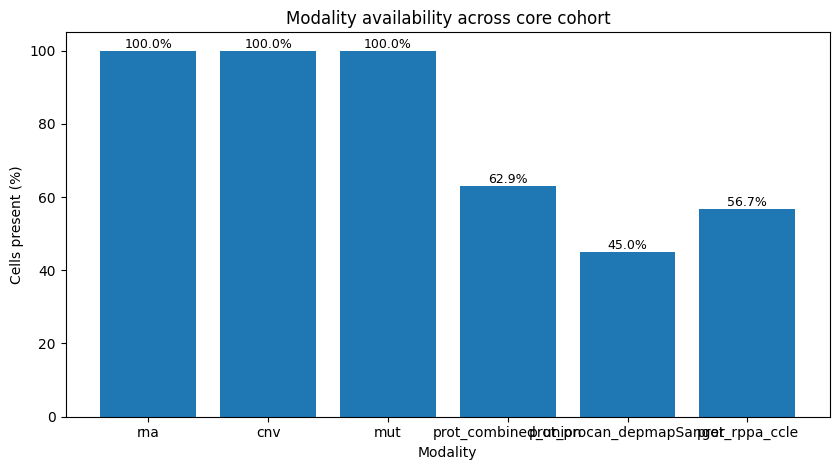

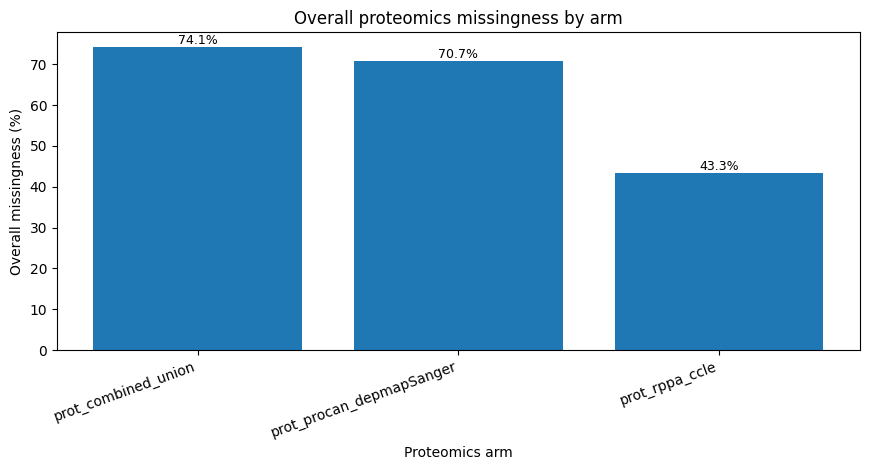

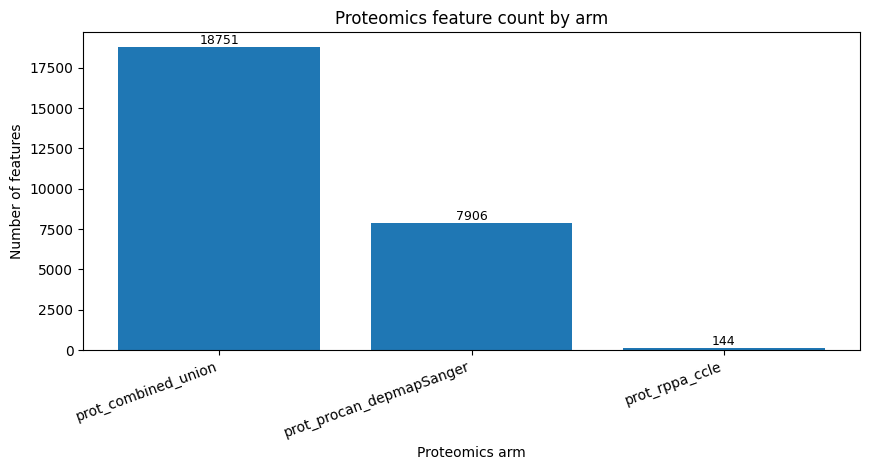

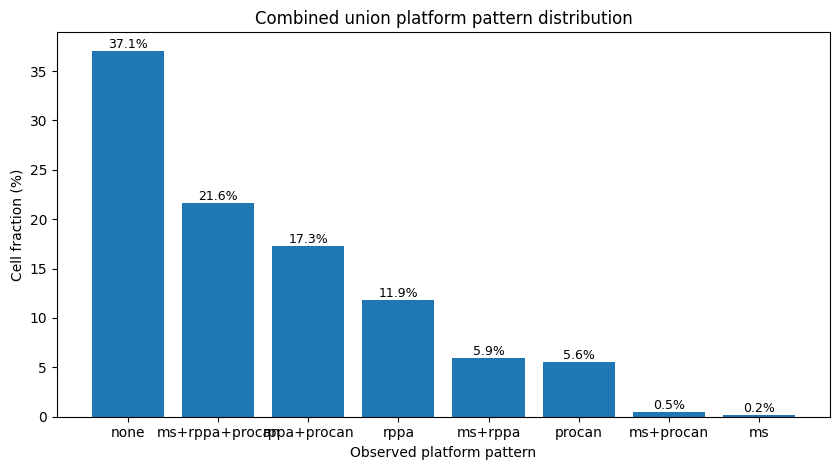

,seed,mean_spearman,median_spearman,std_spearman,n_configs
1,1584678,0.191654,0.194439,0.010941,10
2,17052356,0.191052,0.189890,0.009705,10
0,19537,0.190254,0.192080,0.009855,10


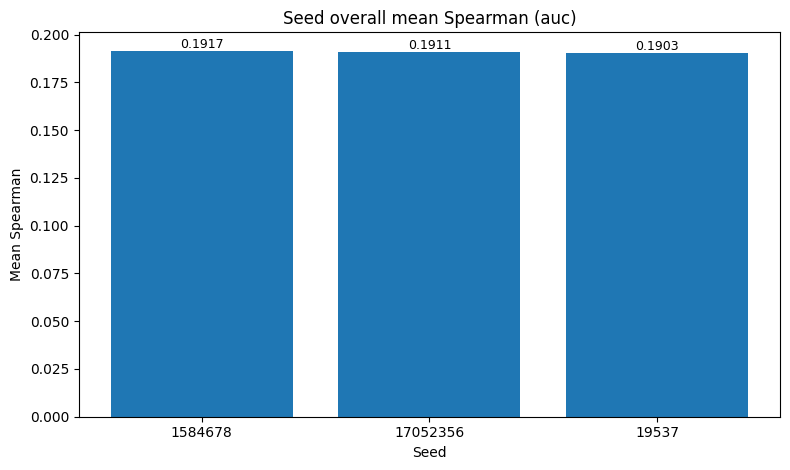

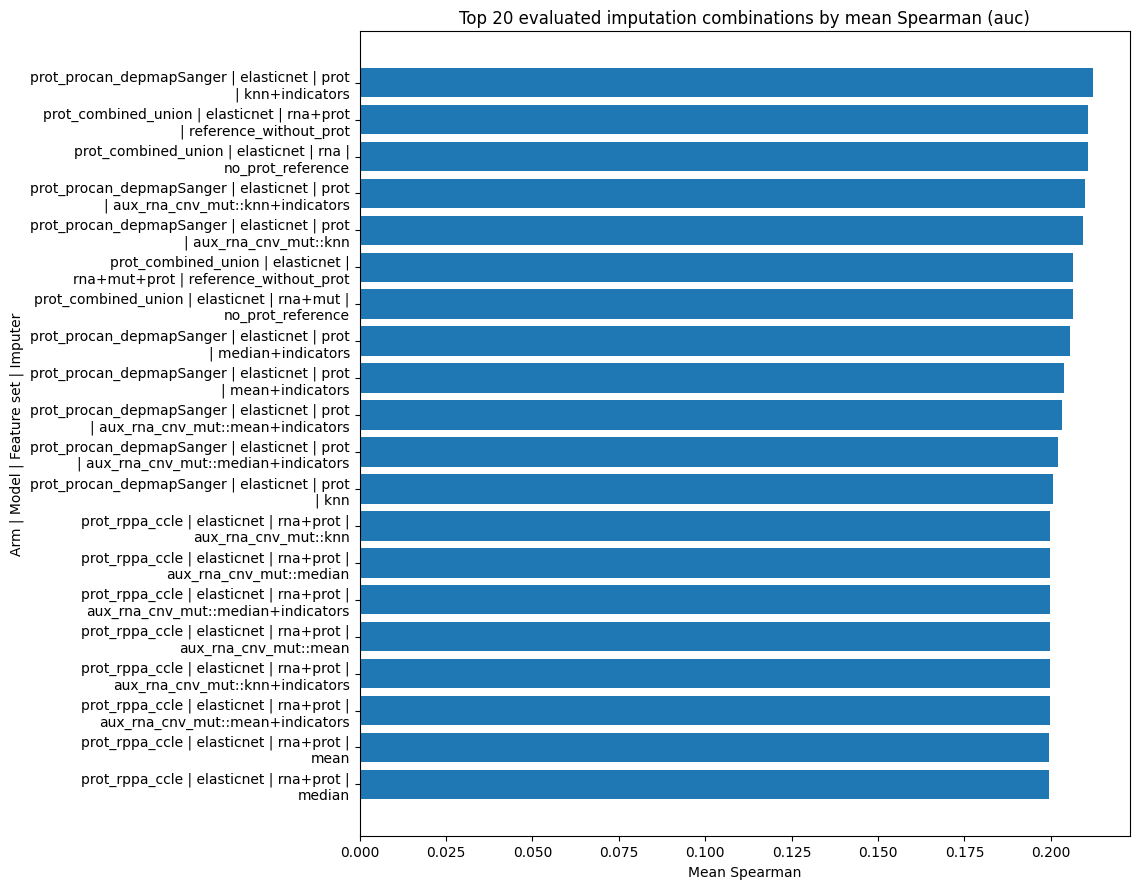

,config_rank,arm,model,feature_set,uses_prot,imputer_strategy,n_seeds,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,baseline_mean_spearman,baseline_strategy,delta_vs_baseline,config_label
0,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::knn,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253,r2 | prot_rppa_ccle | elasticnet | rna+prot
1,5,prot_combined_union,elasticnet,rna+mut+prot,True,mean,3,100,0.179316,0.183035,0.093440,-0.131959,0.206459,reference_without_prot,-0.027142,r5 | prot_combined_union | elasticnet | rna+mu...
2,6,prot_combined_union,elasticnet,rna+prot,True,mean,3,100,0.182223,0.192753,0.098154,-0.127867,0.210839,reference_without_prot,-0.028616,r6 | prot_combined_union | elasticnet | rna+prot
3,7,prot_procan_depmapSanger,elasticnet,rna+mut+prot,True,knn+indicators,3,100,0.190305,0.194512,0.111618,-0.140945,0.181321,reference_without_prot,0.008984,r7 | prot_procan_depmapSanger | elasticnet | r...
4,9,prot_rppa_ccle,elasticnet,rna+mut+prot,True,aux_rna_cnv_mut::knn,3,100,0.192082,0.202327,0.113657,-0.113978,0.191736,reference_without_prot,0.000346,r9 | prot_rppa_ccle | elasticnet | rna+mut+prot
5,10,prot_procan_depmapSanger,elasticnet,prot,True,knn+indicators,3,100,0.212285,0.211442,0.121559,-0.037317,NaN,NaN,NaN,r10 | prot_procan_depmapSanger | elasticnet | ...


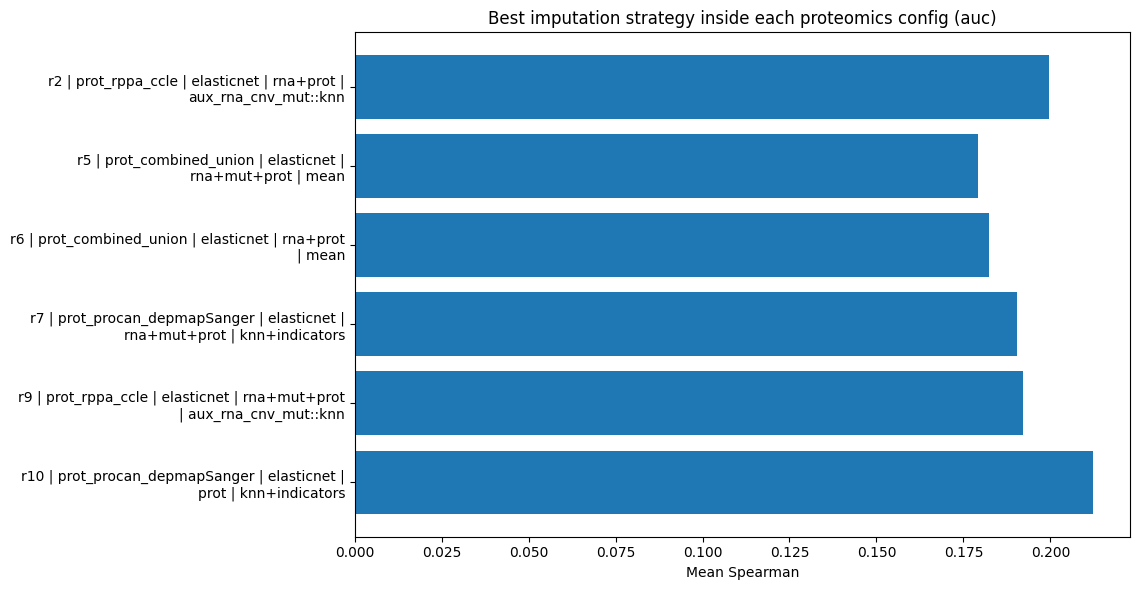

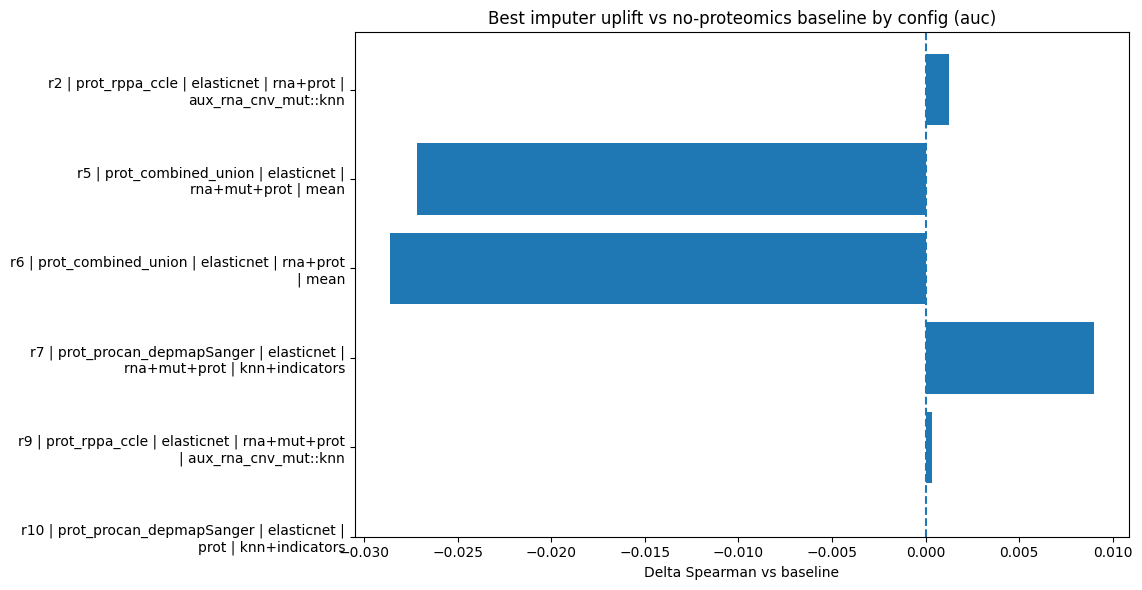

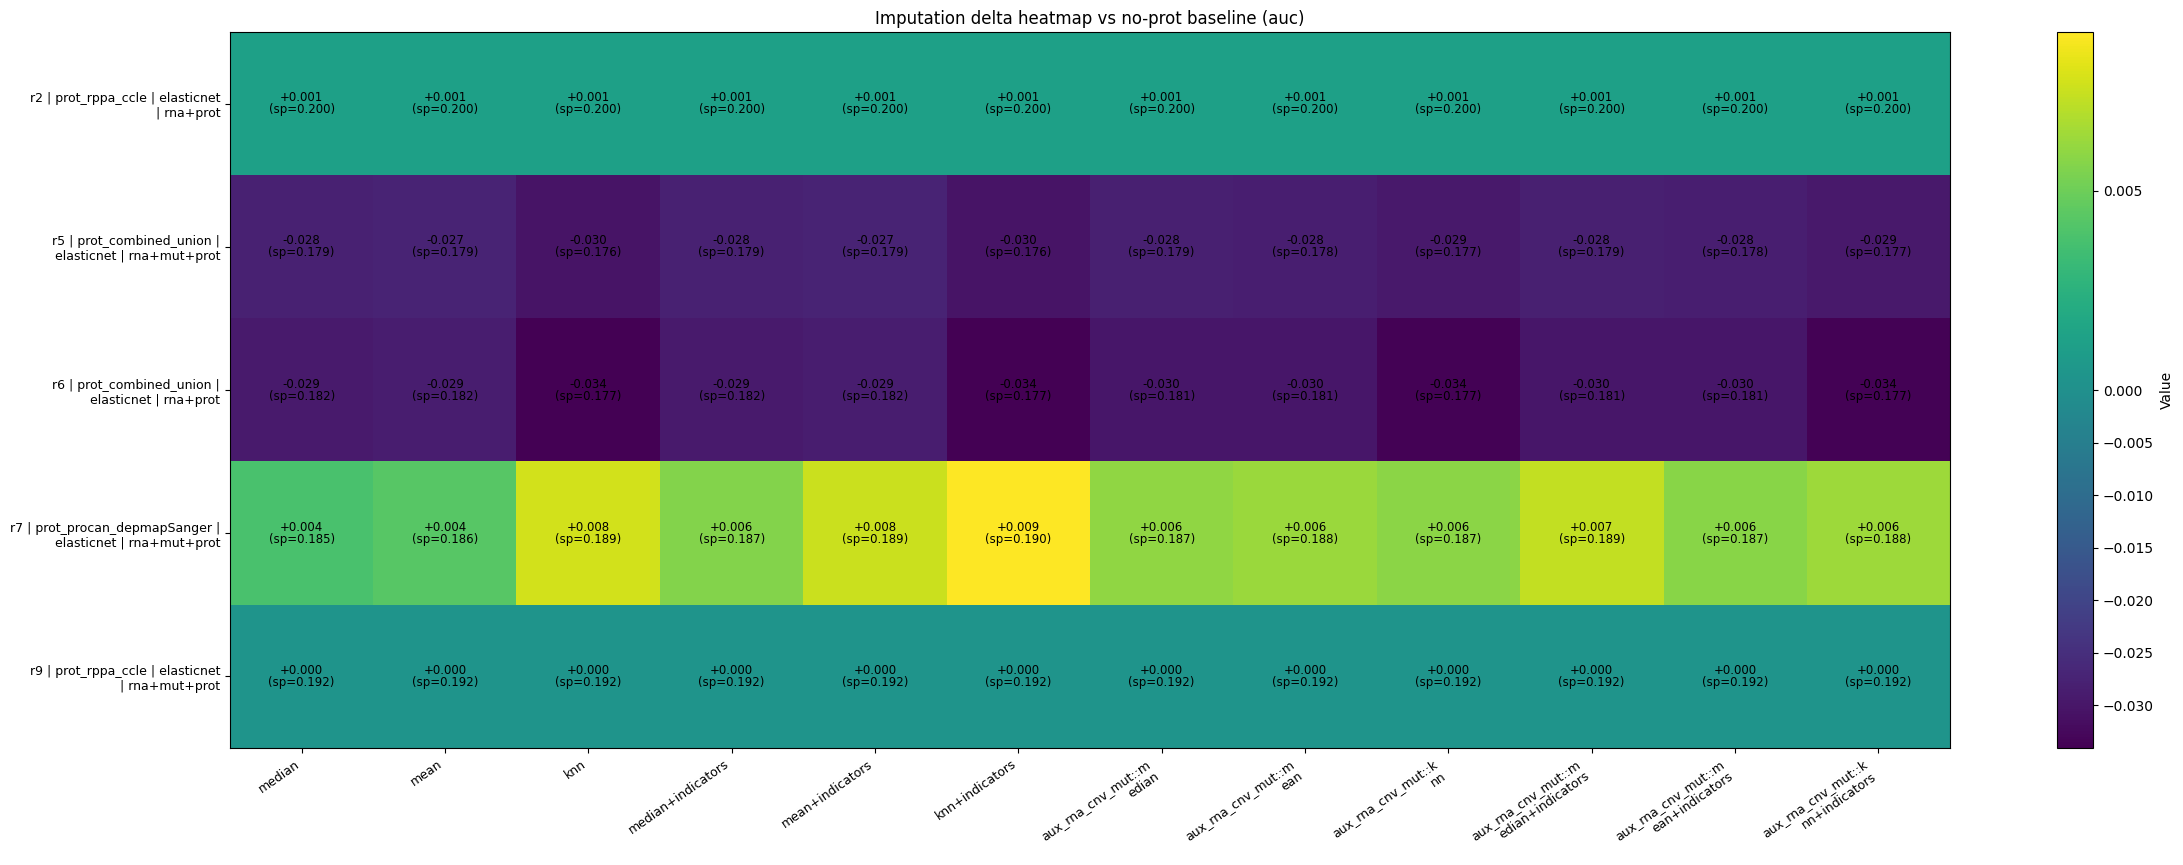

,config_rank,arm,model,feature_set,uses_prot,imputer_strategy,n_seeds,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,baseline_mean_spearman,baseline_strategy,delta_vs_baseline,base_strategy,base_mean_spearman,delta_aux_vs_base,config_label
0,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::knn,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253,knn,0.199608,0.000024,r2 | prot_rppa_ccle | elasticnet | rna+prot
1,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::knn+indicators,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253,knn+indicators,0.199608,0.000024,r2 | prot_rppa_ccle | elasticnet | rna+prot
2,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::mean,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253,mean,0.199608,0.000024,r2 | prot_rppa_ccle | elasticnet | rna+prot
3,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::mean+indicators,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253,mean+indicators,0.199608,0.000024,r2 | prot_rppa_ccle | elasticnet | rna+prot
4,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::median,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253,median,0.199608,0.000024,r2 | prot_rppa_ccle | elasticnet | rna+prot
5,2,prot_rppa_ccle,elasticnet,rna+prot,True,aux_rna_cnv_mut::median+indicators,3,100,0.199632,0.214983,0.115384,-0.099186,0.198380,reference_without_prot,0.001253,median+indicators,0.199608,0.000024,r2 | prot_rppa_ccle | elasticnet | rna+prot
6,5,prot_combined_union,elasticnet,rna+mut+prot,True,aux_rna_cnv_mut::median,3,100,0.178519,0.182908,0.096153,-0.132335,0.206459,reference_without_prot,-0.027940,median,0.178779,-0.000260,r5 | prot_combined_union | elasticnet | rna+mu...
7,5,prot_combined_union,elasticnet,rna+mut+prot,True,aux_rna_cnv_mut::median+indicators,3,100,0.178519,0.182908,0.096153,-0.132335,0.206459,reference_without_prot,-0.027940,median+indicators,0.178779,-0.000260,r5 | prot_combined_union | elasticnet | rna+mu...
8,5,prot_combined_union,elasticnet,rna+mut+prot,True,aux_rna_cnv_mut::mean,3,100,0.178090,0.181224,0.094970,-0.132814,0.206459,reference_without_prot,-0.028368,mean,0.179316,-0.001226,r5 | prot_combined_union | elasticnet | rna+mu...
9,5,prot_combined_union,elasticnet,rna+mut+prot,True,aux_rna_cnv_mut::mean+indicators,3,100,0.178090,0.181224,0.094970,-0.132814,0.206459,reference_without_prot,-0.028368,mean+indicators,0.179316,-0.001226,r5 | prot_combined_union | elasticnet | rna+mu...


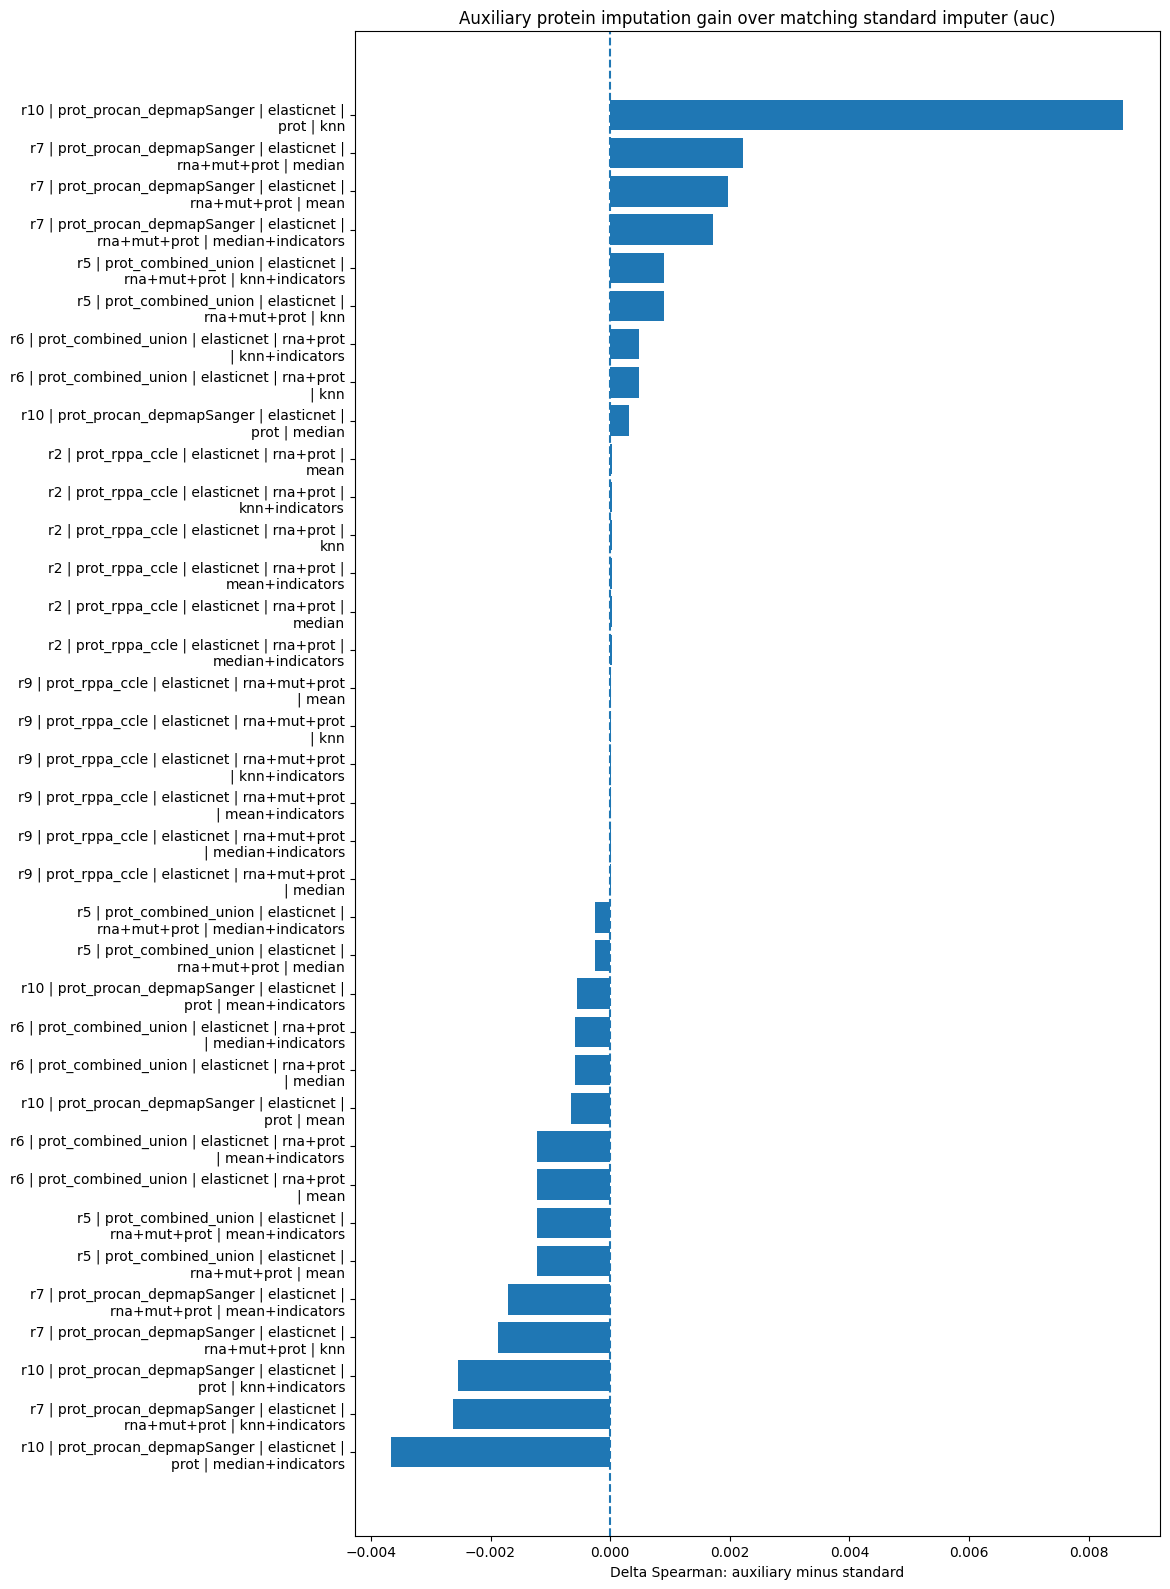

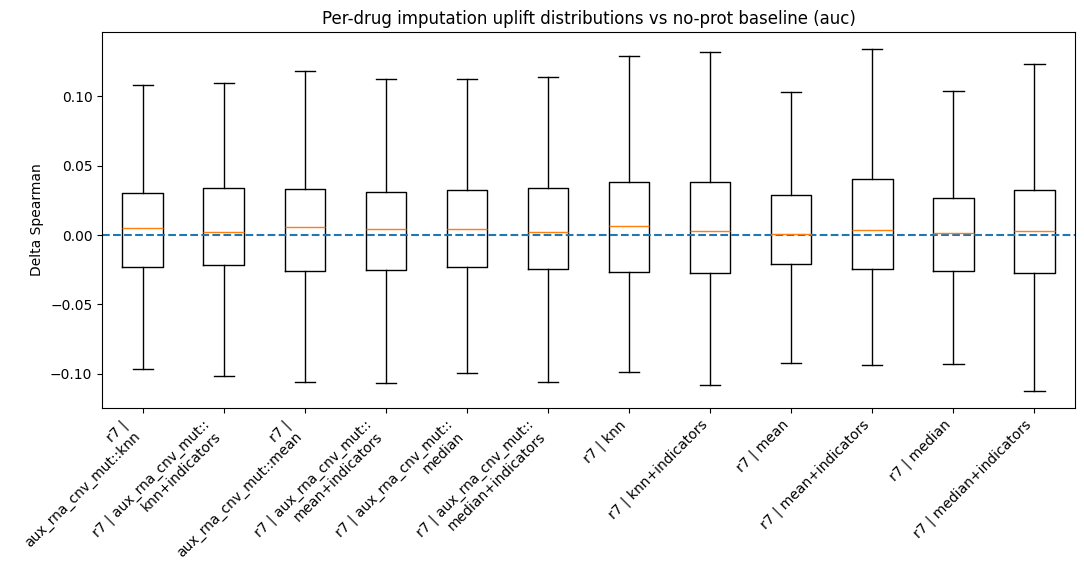

/tmp/ipykernel_733872/1240150393.py:468: FutureWarning: The provided callable <function nanmin at 0x71b4705c2c00> is currently using SeriesGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  .agg(
/tmp/ipykernel_733872/1240150393.py:468: FutureWarning: The provided callable <function nanmax at 0x71b4705c2d40> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  .agg(


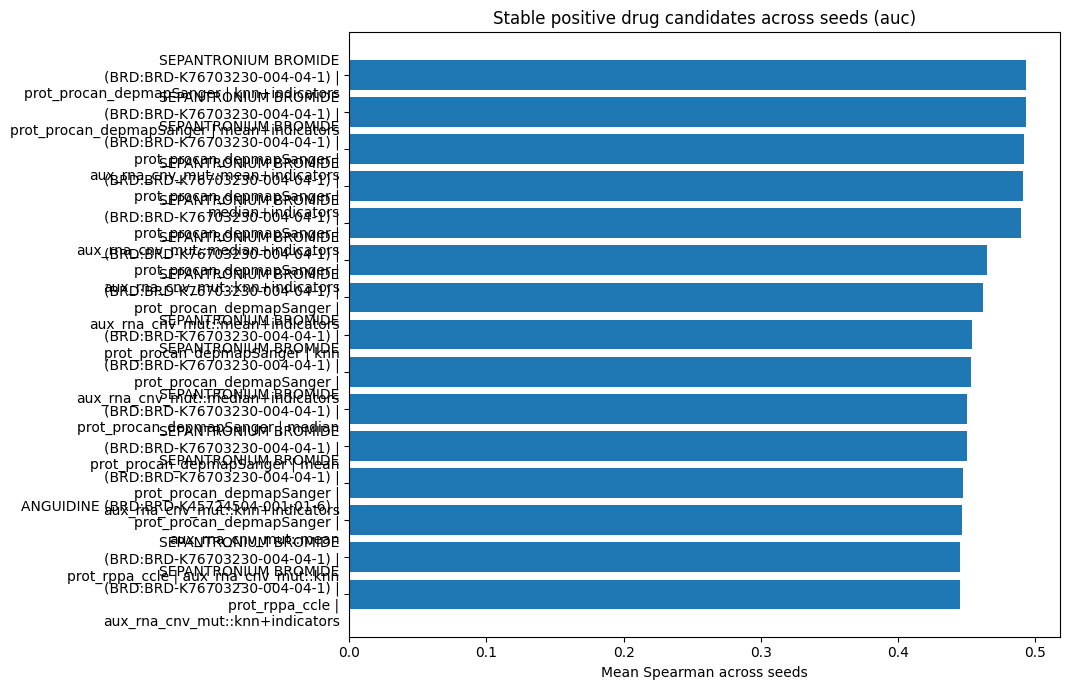

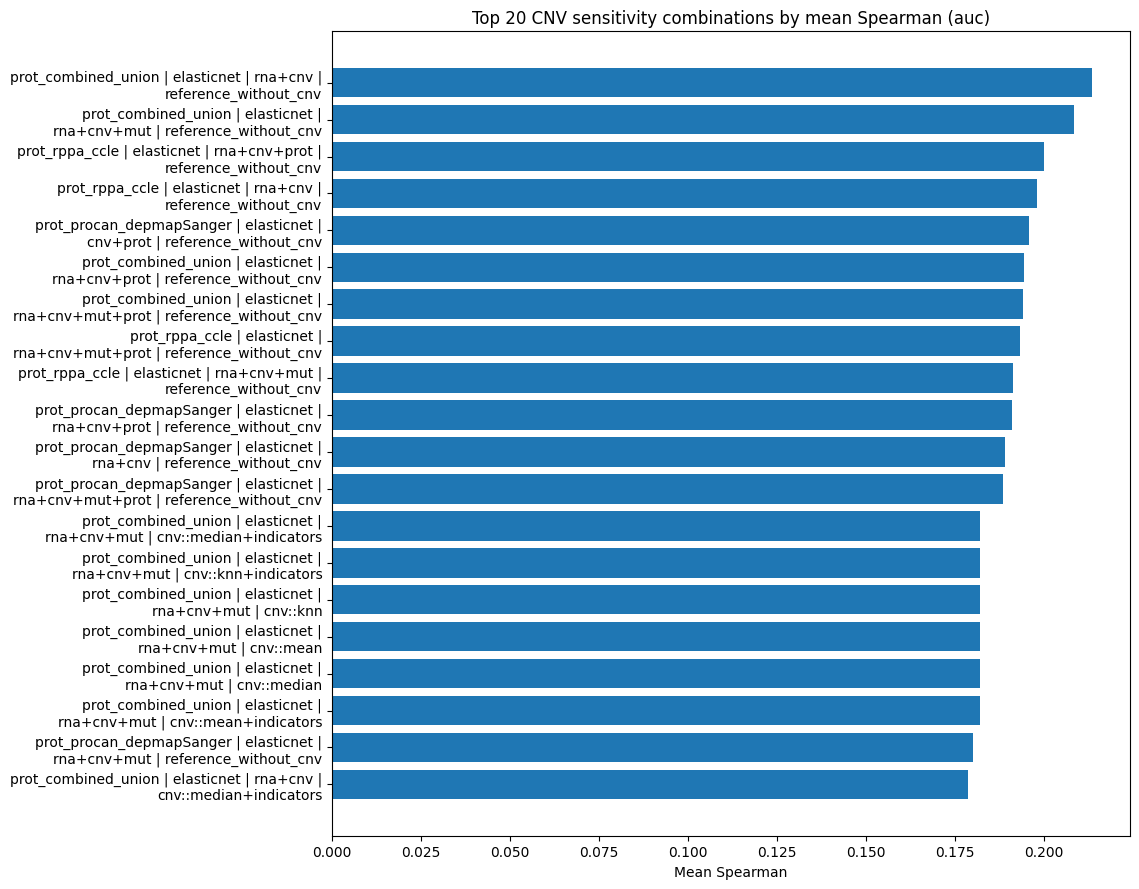

,config_rank,arm,model,feature_set,imputer_strategy,n_seeds,n_drugs,mean_spearman,median_spearman,std_spearman,mean_r2,baseline_mean_spearman,delta_vs_baseline,config_label
0,1000,prot_combined_union,elasticnet,cnv,cnv::knn,3,100,0.104887,0.093526,0.090606,-0.198825,NaN,NaN,r1000 | prot_combined_union | elasticnet | cnv
1,1000,prot_procan_depmapSanger,elasticnet,cnv,cnv::knn,3,100,0.103227,0.107055,0.114733,-0.303694,NaN,NaN,r1000 | prot_procan_depmapSanger | elasticnet ...
2,1000,prot_rppa_ccle,elasticnet,cnv,cnv::knn,3,100,0.101969,0.099451,0.097749,-0.251959,NaN,NaN,r1000 | prot_rppa_ccle | elasticnet | cnv
3,1001,prot_combined_union,elasticnet,rna+cnv,cnv::knn,3,100,0.178703,0.187554,0.102126,-0.187273,0.213526,-0.034823,r1001 | prot_combined_union | elasticnet | rna...
4,1001,prot_rppa_ccle,elasticnet,rna+cnv,cnv::knn,3,100,0.171643,0.171759,0.107711,-0.244297,0.198050,-0.026407,r1001 | prot_rppa_ccle | elasticnet | rna+cnv
5,1001,prot_procan_depmapSanger,elasticnet,rna+cnv,cnv::knn,3,100,0.148836,0.150877,0.112088,-0.344843,0.188961,-0.040125,r1001 | prot_procan_depmapSanger | elasticnet ...
6,1002,prot_combined_union,elasticnet,cnv+mut,cnv::knn,3,100,0.109296,0.102601,0.089780,-0.215351,0.024430,0.084867,r1002 | prot_combined_union | elasticnet | cnv...
7,1002,prot_rppa_ccle,elasticnet,cnv+mut,cnv::knn,3,100,0.104630,0.103687,0.095916,-0.260574,0.010069,0.094561,r1002 | prot_rppa_ccle | elasticnet | cnv+mut
8,1002,prot_procan_depmapSanger,elasticnet,cnv+mut,cnv::knn,3,100,0.100899,0.092675,0.107076,-0.329569,0.013958,0.086941,r1002 | prot_procan_depmapSanger | elasticnet ...
9,1003,prot_combined_union,elasticnet,rna+cnv+mut,cnv::knn,3,100,0.182002,0.187280,0.100522,-0.192620,0.208483,-0.026481,r1003 | prot_combined_union | elasticnet | rna...


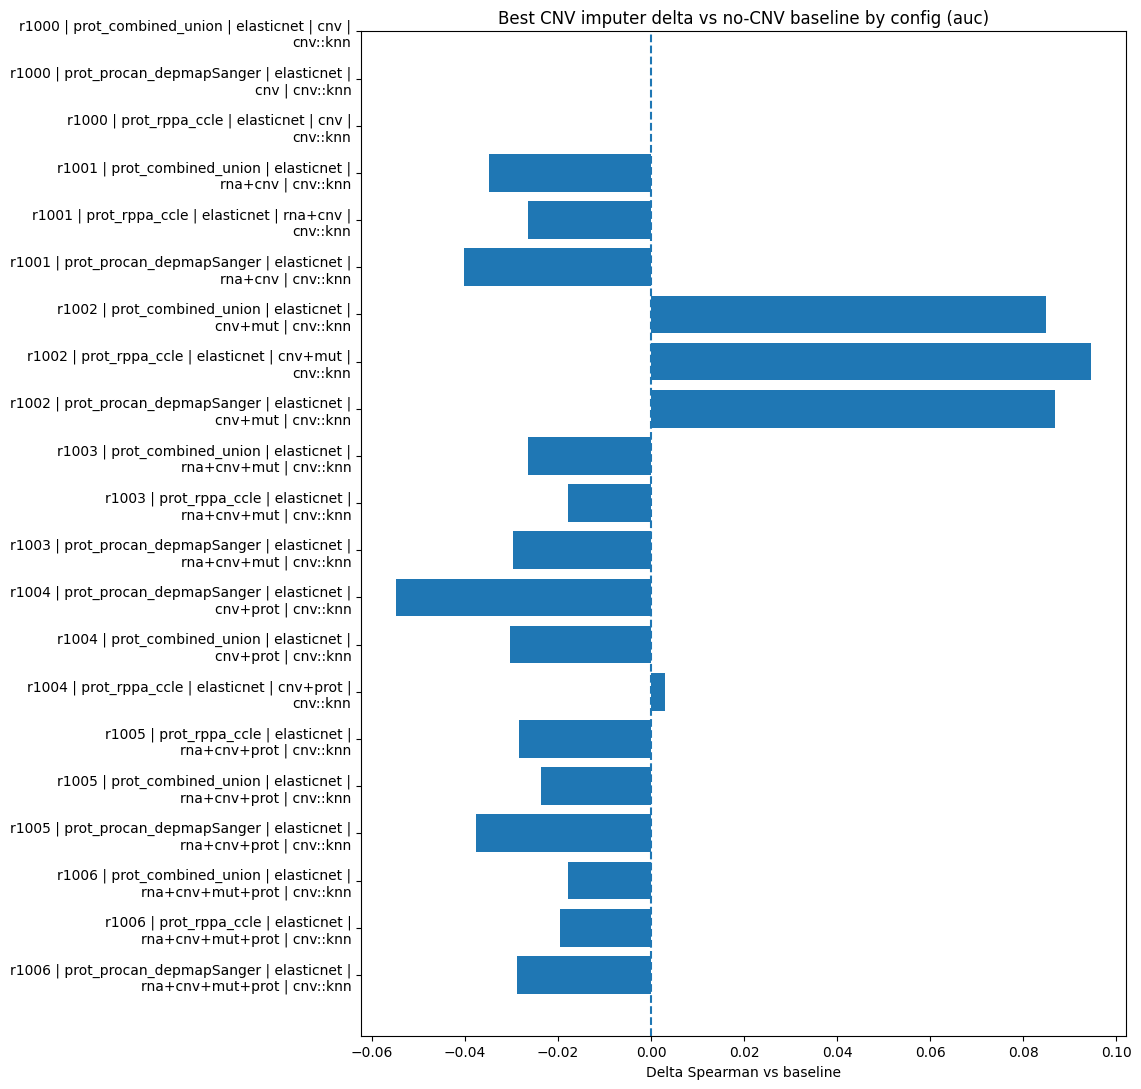

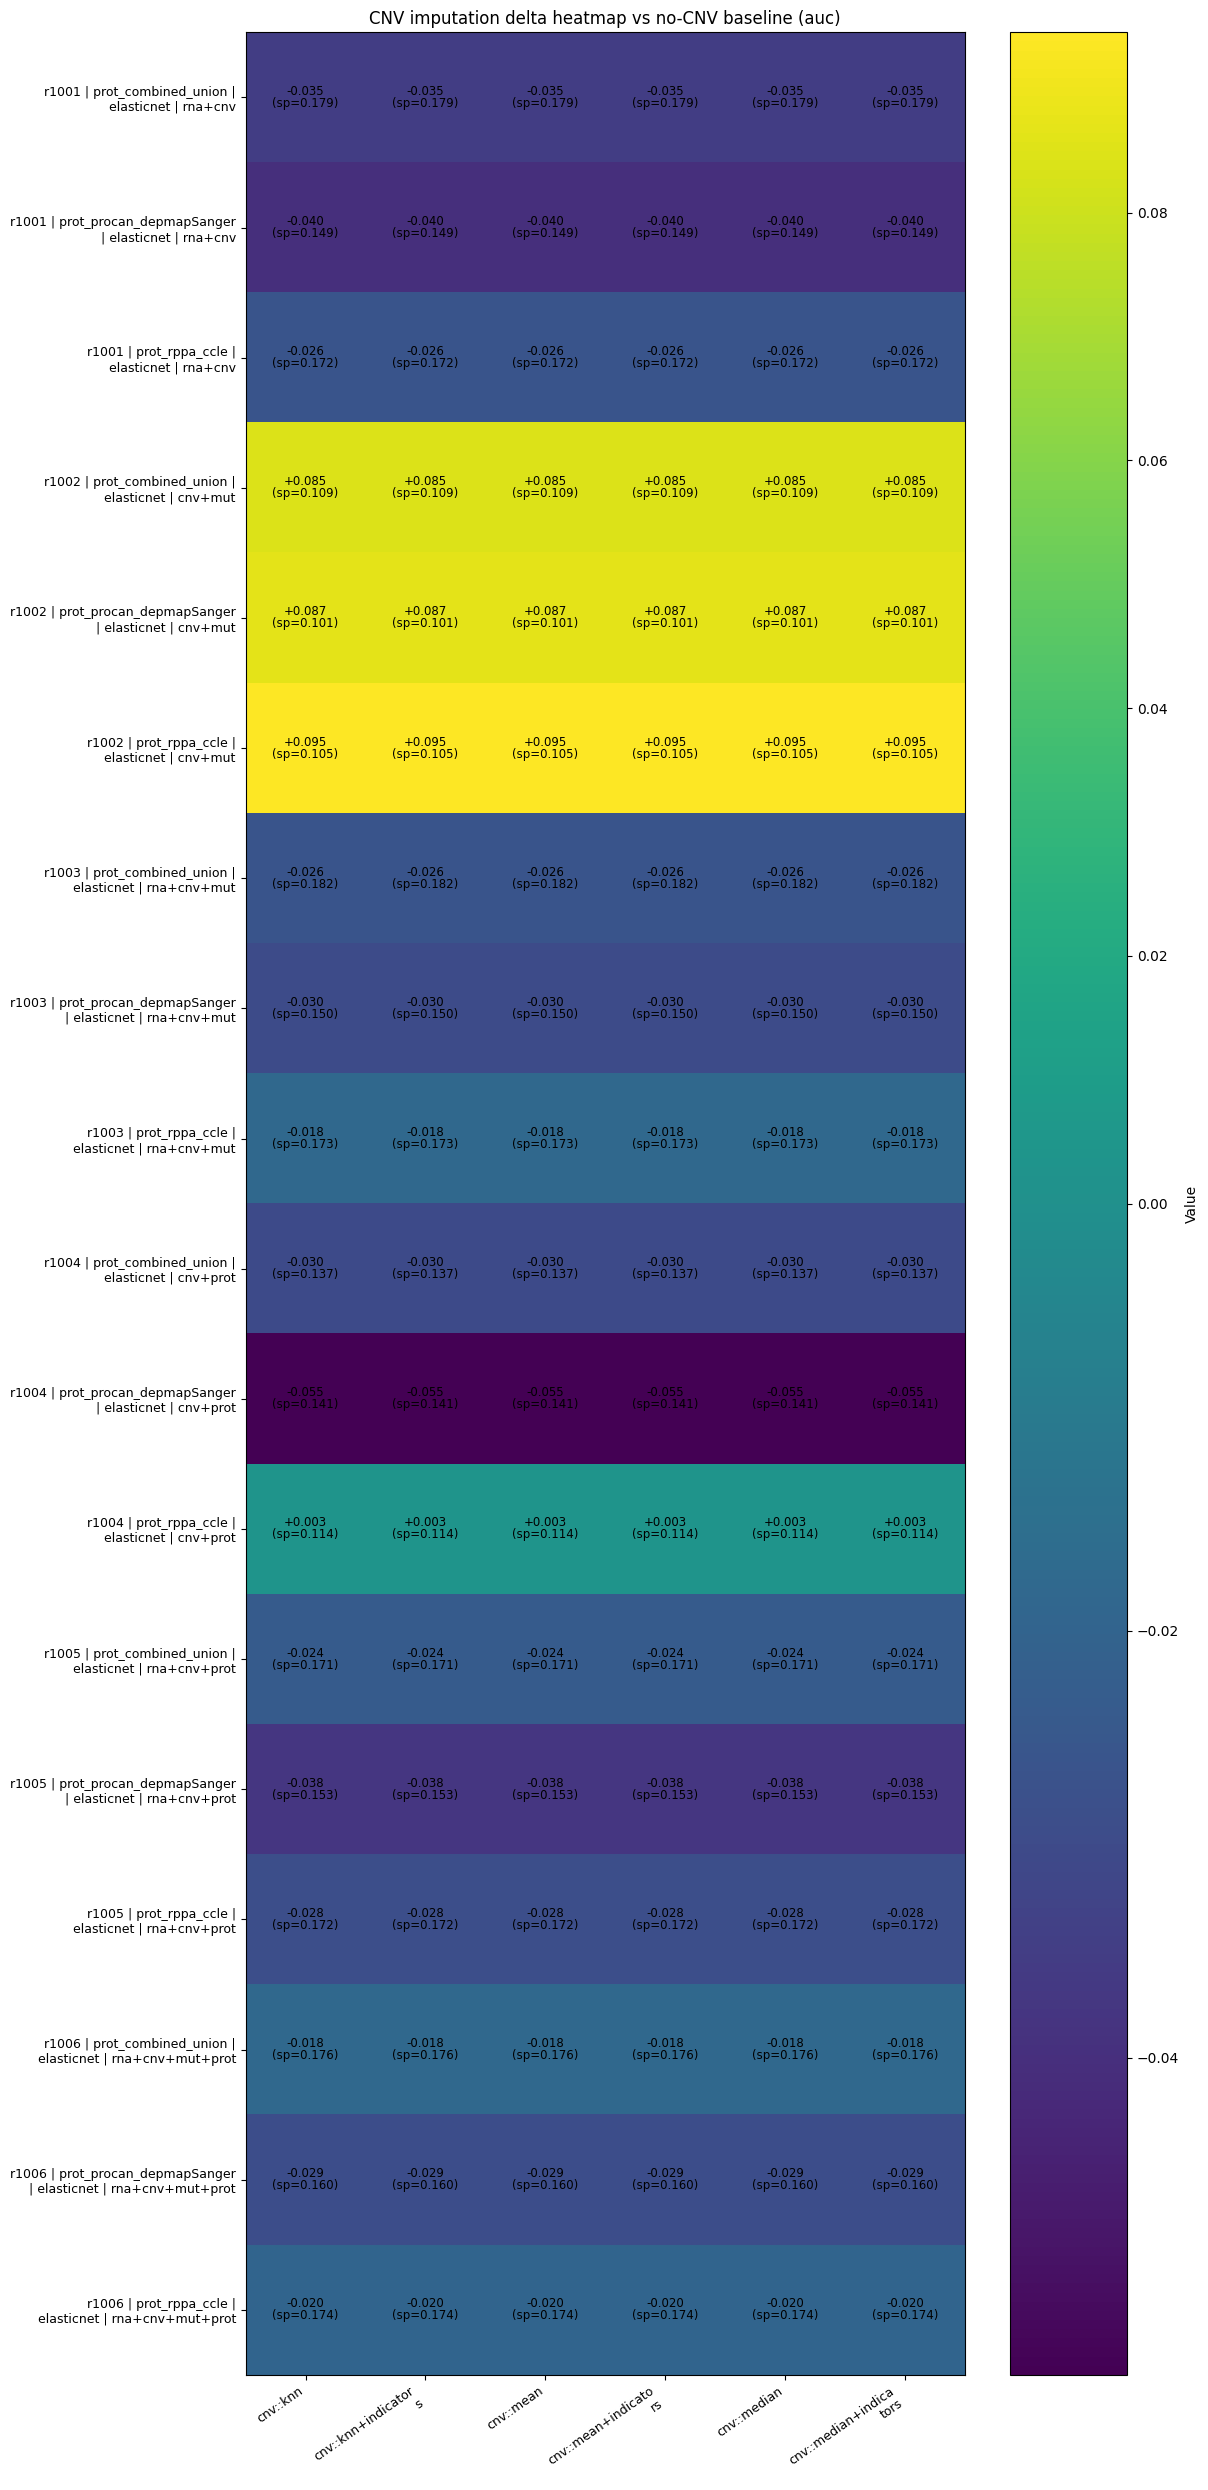

,artefact,path
0,proteomics_detail_csv,artifacts/reports/notebook 4/impute_bakeoff_me...
1,proteomics_summary_csv,artifacts/reports/notebook 4/impute_bakeoff_su...
2,proteomics_per_seed_summary_csv,artifacts/reports/notebook 4/impute_bakeoff_pe...
3,cnv_detail_csv,artifacts/reports/notebook 4/cnv_impute_bakeof...
4,cnv_summary_csv,artifacts/reports/notebook 4/cnv_impute_bakeof...
5,missingness_report_json,artifacts/reports/notebook 4/missingness_repor...
6,imputer_choice_json,artifacts/metadata/notebook 4/imputer_choice.json
7,cnv_choice_json,artifacts/metadata/notebook 4/cnv_imputer_choi...
8,figures_dir,artifacts/reports/notebook 4/figures
9,interpretability_dir,artifacts/reports/notebook 4/interpretability


Artefact index written: artifacts/reports/notebook 4/artefact_index.json


In [5]:
# Output folders
FIG_DIR = OUT_REPORTS / "figures"
INTERP_DIR = OUT_REPORTS / "interpretability"
FIG_DIR.mkdir(parents=True, exist_ok=True)
INTERP_DIR.mkdir(parents=True, exist_ok=True)

print("Saving evaluation figures to:", FIG_DIR)
print("Saving interpretability outputs to:", INTERP_DIR)

def safe_filename(s: str) -> str:
    return (
        str(s)
        .replace("/", "_")
        .replace("\\", "_")
        .replace(" ", "_")
        .replace("+", "plus")
        .replace(":", "_")
        .replace("|", "_")
    )

def wrap_label(s: str, width: int = 24) -> str:
    return "\n".join(textwrap.wrap(str(s), width=width))

def finish_plot(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, dpi=170, bbox_inches="tight")
    plt.show()
    plt.close()

def draw_matrix_heatmap(
    mat: pd.DataFrame,
    title: str,
    out_path: Path,
    centre_zero: bool = False,
    annotate_fmt: str = "{:.3f}",
    extra_annot: Optional[pd.DataFrame] = None,
):
    if mat.empty:
        print(f"[skip] {title}: empty matrix")
        return

    arr = mat.to_numpy(dtype=float)
    finite = np.isfinite(arr)
    if not finite.any():
        print(f"[skip] {title}: no finite values")
        return

    vmin = float(np.nanmin(arr))
    vmax = float(np.nanmax(arr))

    plt.figure(figsize=(2.0 * max(4, mat.shape[1]), 1.25 * max(4, mat.shape[0]) + 2.5))
    if centre_zero:
        norm = TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
        im = plt.imshow(arr, aspect="auto", norm=norm)
    else:
        im = plt.imshow(arr, aspect="auto")

    plt.colorbar(im, label="Value")
    plt.xticks(
        range(mat.shape[1]),
        [wrap_label(c, 18) for c in mat.columns],
        rotation=35,
        ha="right",
        fontsize=9,
    )
    plt.yticks(
        range(mat.shape[0]),
        [wrap_label(i, 32) for i in mat.index],
        fontsize=9,
    )
    plt.title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = arr[i, j]
            if np.isfinite(val):
                txt = annotate_fmt.format(val)
                if extra_annot is not None:
                    ev = extra_annot.iloc[i, j]
                    if pd.notna(ev):
                        txt = f"{txt}\n({ev})"
                plt.text(j, i, txt, ha="center", va="center", fontsize=8.5, linespacing=0.9)

    plt.subplots_adjust(left=0.30, bottom=0.22, right=0.96, top=0.88)
    finish_plot(out_path)

def config_label_from_cols(df: pd.DataFrame) -> pd.Series:
    return (
        "r" + df["config_rank"].astype(str)
        + " | " + df["arm"].astype(str)
        + " | " + df["model"].astype(str)
        + " | " + df["feature_set"].astype(str)
    )

def safe_mean(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(x.mean()) if x.size else np.nan

def safe_median(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if x.size else np.nan

def safe_std(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(x.std()) if x.size else np.nan

prot_summary_all = bakeoff_summary.copy()
prot_detail_all = bakeoff_df.copy()
cnv_summary_all = cnv_summary.copy() if "cnv_summary" in globals() else pd.DataFrame()
cnv_detail_all = cnv_bakeoff_df.copy() if "cnv_bakeoff_df" in globals() else pd.DataFrame()

for df_name in ["prot_summary_all", "prot_detail_all", "cnv_summary_all", "cnv_detail_all"]:
    if df_name in globals():
        pass

if prot_summary_all.shape[0] > 0:
    for c in ["config_rank", "mean_spearman", "median_spearman", "std_spearman", "mean_r2", "delta_vs_baseline"]:
        if c in prot_summary_all.columns:
            prot_summary_all[c] = pd.to_numeric(prot_summary_all[c], errors="coerce")

if prot_detail_all.shape[0] > 0:
    for c in ["seed", "config_rank", "fold", "spearman", "r2", "n_train", "n_test"]:
        if c in prot_detail_all.columns:
            prot_detail_all[c] = pd.to_numeric(prot_detail_all[c], errors="coerce")

if cnv_summary_all.shape[0] > 0:
    for c in ["config_rank", "mean_spearman", "median_spearman", "std_spearman", "mean_r2", "delta_vs_baseline"]:
        if c in cnv_summary_all.columns:
            cnv_summary_all[c] = pd.to_numeric(cnv_summary_all[c], errors="coerce")

if cnv_detail_all.shape[0] > 0:
    for c in ["seed", "config_rank", "fold", "spearman", "r2", "n_train", "n_test"]:
        if c in cnv_detail_all.columns:
            cnv_detail_all[c] = pd.to_numeric(cnv_detail_all[c], errors="coerce")

# Missingness and availability plots

# Modality availability
if isinstance(avail_summary, pd.DataFrame) and avail_summary.shape[0] > 0:
    tmp = avail_summary.reset_index().copy()
    tmp["label"] = tmp.iloc[:, 0].astype(str)

    plt.figure(figsize=(8.5, 4.8))
    plt.bar(tmp["label"], tmp["pct_present"])
    for i, v in enumerate(tmp["pct_present"].tolist()):
        plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.title("Modality availability across core cohort")
    plt.xlabel("Modality")
    plt.ylabel("Cells present (%)")
    finish_plot(FIG_DIR / "modality_availability_pct.png")

# Proteomics arm missingness
if isinstance(feat_miss_df, pd.DataFrame) and feat_miss_df.shape[0] > 0:
    tmp = feat_miss_df.sort_values("overall_missing_pct", ascending=False).copy()

    plt.figure(figsize=(8.8, 4.8))
    plt.bar(tmp["arm"], tmp["overall_missing_pct"])
    for i, v in enumerate(tmp["overall_missing_pct"].tolist()):
        plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.title("Overall proteomics missingness by arm")
    plt.xlabel("Proteomics arm")
    plt.ylabel("Overall missingness (%)")
    plt.xticks(rotation=20, ha="right")
    finish_plot(FIG_DIR / "proteomics_arm_missingness.png")

# Number of features by arm
if isinstance(feat_miss_df, pd.DataFrame) and feat_miss_df.shape[0] > 0:
    tmp = feat_miss_df.sort_values("n_features", ascending=False).copy()

    plt.figure(figsize=(8.8, 4.8))
    plt.bar(tmp["arm"], tmp["n_features"])
    for i, v in enumerate(tmp["n_features"].tolist()):
        plt.text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=9)
    plt.title("Proteomics feature count by arm")
    plt.xlabel("Proteomics arm")
    plt.ylabel("Number of features")
    plt.xticks(rotation=20, ha="right")
    finish_plot(FIG_DIR / "proteomics_arm_feature_counts.png")

# Combined union patterns
if "pat_counts" in globals() and isinstance(pat_counts, pd.DataFrame) and pat_counts.shape[0] > 0:
    tmp = pat_counts.copy()

    plt.figure(figsize=(8.5, 4.8))
    plt.bar(tmp["pattern"], tmp["frac_cells"] * 100.0)
    for i, v in enumerate((tmp["frac_cells"] * 100.0).tolist()):
        plt.text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
    plt.title("Combined union platform pattern distribution")
    plt.xlabel("Observed platform pattern")
    plt.ylabel("Cell fraction (%)")
    finish_plot(FIG_DIR / "combined_union_platform_patterns.png")

# Seed-level summary

if isinstance(per_seed_summary, pd.DataFrame) and per_seed_summary.shape[0] > 0:
    seed_overall = (
        per_seed_summary
        .groupby("seed", as_index=False)
        .agg(
            mean_spearman=("mean_spearman", safe_mean),
            median_spearman=("mean_spearman", safe_median),
            std_spearman=("mean_spearman", safe_std),
            n_configs=("config_rank", "nunique"),
        )
        .sort_values("mean_spearman", ascending=False)
    )

    seed_overall.to_csv(OUT_REPORTS / "seed_overall_summary_from_impute_bakeoff.csv", index=False)
    display(seed_overall)

    plt.figure(figsize=(8, 4.8))
    plt.bar(seed_overall["seed"].astype(str), seed_overall["mean_spearman"])
    for i, v in enumerate(seed_overall["mean_spearman"].tolist()):
        plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
    plt.title(f"Seed overall mean Spearman ({PRIMARY_TARGET})")
    plt.xlabel("Seed")
    plt.ylabel("Mean Spearman")
    finish_plot(FIG_DIR / f"seed_overall_mean_spearman_{PRIMARY_TARGET}.png")

# Top combinations overall

if prot_summary_all.shape[0] > 0:
    feature_combo_ranking = prot_summary_all.copy()
    feature_combo_ranking["label"] = (
        feature_combo_ranking["arm"].astype(str)
        + " | "
        + feature_combo_ranking["model"].astype(str)
        + " | "
        + feature_combo_ranking["feature_set"].astype(str)
        + " | "
        + feature_combo_ranking["imputer_strategy"].astype(str)
    )

    topk = (
        feature_combo_ranking
        .sort_values("mean_spearman", ascending=False)
        .head(20)
        .copy()
    )

    topk.to_csv(OUT_REPORTS / "top20_imputation_combinations.csv", index=False)

    plt.figure(figsize=(11.5, max(6, int(0.42 * len(topk) + 1))))
    plt.barh(range(len(topk)), topk["mean_spearman"])
    plt.yticks(range(len(topk)), [wrap_label(x, 44) for x in topk["label"]])
    plt.gca().invert_yaxis()
    plt.title(f"Top 20 evaluated imputation combinations by mean Spearman ({PRIMARY_TARGET})")
    plt.xlabel("Mean Spearman")
    plt.ylabel("Arm | Model | Feature set | Imputer")
    finish_plot(FIG_DIR / f"top20_imputation_combinations_{PRIMARY_TARGET}.png")

# Best imputer inside each ranked proteomics config

prot_only_summary = prot_summary_all[
    (prot_summary_all["uses_prot"] == True)
    & (~prot_summary_all["imputer_strategy"].isin(["no_prot_reference", "reference_without_prot"]))
].copy()

if prot_only_summary.shape[0] > 0:
    best_imputer_by_config = (
        prot_only_summary
        .sort_values(["config_rank", "mean_spearman"], ascending=[True, False])
        .groupby(["config_rank", "arm", "model", "feature_set"], as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    best_imputer_by_config["config_label"] = config_label_from_cols(best_imputer_by_config)
    best_imputer_by_config.to_csv(OUT_REPORTS / "best_imputer_by_config.csv", index=False)
    display(best_imputer_by_config)

    plt.figure(figsize=(11.5, max(6, int(0.48 * len(best_imputer_by_config) + 1))))
    plt.barh(range(len(best_imputer_by_config)), best_imputer_by_config["mean_spearman"])
    plt.yticks(
        range(len(best_imputer_by_config)),
        [wrap_label(f"{a} | {b}", 48) for a, b in zip(best_imputer_by_config["config_label"], best_imputer_by_config["imputer_strategy"])]
    )
    plt.gca().invert_yaxis()
    plt.title(f"Best imputation strategy inside each proteomics config ({PRIMARY_TARGET})")
    plt.xlabel("Mean Spearman")
    finish_plot(FIG_DIR / f"best_imputer_by_config_{PRIMARY_TARGET}.png")

    plt.figure(figsize=(11.5, max(6, int(0.48 * len(best_imputer_by_config) + 1))))
    plt.barh(range(len(best_imputer_by_config)), best_imputer_by_config["delta_vs_baseline"])
    plt.yticks(
        range(len(best_imputer_by_config)),
        [wrap_label(f"{a} | {b}", 48) for a, b in zip(best_imputer_by_config["config_label"], best_imputer_by_config["imputer_strategy"])]
    )
    plt.gca().invert_yaxis()
    plt.axvline(0.0, linestyle="--")
    plt.title(f"Best imputer uplift vs no-proteomics baseline by config ({PRIMARY_TARGET})")
    plt.xlabel("Delta Spearman vs baseline")
    finish_plot(FIG_DIR / f"best_imputer_delta_vs_baseline_{PRIMARY_TARGET}.png")

# Imputer delta heatmap

if prot_only_summary.shape[0] > 0:
    heat = prot_only_summary.copy()
    heat["config_label"] = config_label_from_cols(heat)

    strategy_order = [
        "median",
        "mean",
        "knn",
        "median+indicators",
        "mean+indicators",
        "knn+indicators",
    ]

    aux_prefix = f"{AUX_FOR_PROT_NAME}::" if "AUX_FOR_PROT_NAME" in globals() else "aux_rna_cnv_mut::"
    aux_order = [f"{aux_prefix}{x}" for x in strategy_order]

    ordered_cols = [c for c in strategy_order + aux_order if c in heat["imputer_strategy"].unique().tolist()]
    remaining_cols = [c for c in heat["imputer_strategy"].unique().tolist() if c not in ordered_cols]
    full_col_order = ordered_cols + sorted(remaining_cols)

    hm = (
        heat.pivot_table(
            index="config_label",
            columns="imputer_strategy",
            values="delta_vs_baseline",
            aggfunc="mean",
        )
        .reindex(columns=full_col_order)
    )

    ann = (
        heat.assign(lbl=heat["mean_spearman"].map(lambda x: f"sp={x:.3f}" if pd.notna(x) else ""))
        .pivot_table(index="config_label", columns="imputer_strategy", values="lbl", aggfunc="first")
        .reindex(index=hm.index, columns=hm.columns)
    )

    draw_matrix_heatmap(
        hm,
        title=f"Imputation delta heatmap vs no-prot baseline ({PRIMARY_TARGET})",
        out_path=FIG_DIR / f"imputer_delta_heatmap_{PRIMARY_TARGET}.png",
        centre_zero=True,
        annotate_fmt="{:+.3f}",
        extra_annot=ann,
    )

# Auxiliary imputation versus standard imputation

if prot_only_summary.shape[0] > 0:
    aux_prefix = f"{AUX_FOR_PROT_NAME}::" if "AUX_FOR_PROT_NAME" in globals() else "aux_rna_cnv_mut::"

    aux_rows = prot_only_summary[
        prot_only_summary["imputer_strategy"].astype(str).str.startswith(aux_prefix)
    ].copy()

    if aux_rows.shape[0] > 0:
        aux_rows["base_strategy"] = aux_rows["imputer_strategy"].astype(str).str.replace(aux_prefix, "", regex=False)

        base_rows = prot_only_summary[
            prot_only_summary["imputer_strategy"].isin(aux_rows["base_strategy"].unique())
        ].copy()
        base_rows = base_rows.rename(columns={"imputer_strategy": "base_strategy", "mean_spearman": "base_mean_spearman"})

        aux_cmp = aux_rows.merge(
            base_rows[
                ["config_rank", "arm", "model", "feature_set", "base_strategy", "base_mean_spearman"]
            ],
            on=["config_rank", "arm", "model", "feature_set", "base_strategy"],
            how="left",
        )

        aux_cmp["delta_aux_vs_base"] = aux_cmp["mean_spearman"] - aux_cmp["base_mean_spearman"]
        aux_cmp["config_label"] = config_label_from_cols(aux_cmp)
        aux_cmp.to_csv(OUT_REPORTS / "auxiliary_protein_imputation_comparison.csv", index=False)
        display(aux_cmp)

        plot_df = aux_cmp.sort_values("delta_aux_vs_base", ascending=False).copy()
        plot_df["label"] = plot_df["config_label"] + " | " + plot_df["base_strategy"]

        plt.figure(figsize=(11.8, max(6, int(0.44 * len(plot_df) + 1))))
        plt.barh(range(len(plot_df)), plot_df["delta_aux_vs_base"])
        plt.yticks(range(len(plot_df)), [wrap_label(x, 48) for x in plot_df["label"]])
        plt.gca().invert_yaxis()
        plt.axvline(0.0, linestyle="--")
        plt.title(f"Auxiliary protein imputation gain over matching standard imputer ({PRIMARY_TARGET})")
        plt.xlabel("Delta Spearman: auxiliary minus standard")
        finish_plot(FIG_DIR / f"auxiliary_protein_imputation_gain_{PRIMARY_TARGET}.png")

# Per-drug imputation delta distributions

if prot_detail_all.shape[0] > 0:
    prot_drug_means = (
        prot_detail_all
        .groupby(
            ["seed", "config_rank", "arm", "model", "feature_set", "imputer_strategy", "compound_id"],
            as_index=False,
        )
        .agg(
            spearman=("spearman", safe_mean),
            r2=("r2", safe_mean),
        )
    )

    prot_ref = (
        prot_drug_means[prot_drug_means["imputer_strategy"] == "reference_without_prot"][
            ["seed", "config_rank", "arm", "model", "feature_set", "compound_id", "spearman"]
        ]
        .rename(columns={"spearman": "ref_spearman"})
    )

    per_drug_imputation_delta = prot_drug_means.merge(
        prot_ref,
        on=["seed", "config_rank", "arm", "model", "feature_set", "compound_id"],
        how="left",
    )

    per_drug_imputation_delta = per_drug_imputation_delta[
        ~per_drug_imputation_delta["imputer_strategy"].isin(["no_prot_reference", "reference_without_prot"])
    ].copy()

    per_drug_imputation_delta["delta_spearman"] = (
        per_drug_imputation_delta["spearman"] - per_drug_imputation_delta["ref_spearman"]
    )
    per_drug_imputation_delta["combo"] = (
        "r" + per_drug_imputation_delta["config_rank"].astype(int).astype(str)
        + " | "
        + per_drug_imputation_delta["imputer_strategy"].astype(str)
    )

    combo_rank = (
        per_drug_imputation_delta
        .groupby("combo", as_index=False)
        .agg(mean_delta=("delta_spearman", safe_mean))
        .sort_values("mean_delta", ascending=False)
        .head(12)
    )

    box_df = per_drug_imputation_delta[
        per_drug_imputation_delta["combo"].isin(combo_rank["combo"].tolist())
    ].copy()

    groups = list(box_df.groupby("combo", sort=False))
    if len(groups) > 0:
        labels = [str(k) for k, _ in groups]
        data = [g["delta_spearman"].dropna().to_numpy(dtype=float) for _, g in groups]

        plt.figure(figsize=(max(11, int(0.62 * len(labels) + 2)), 5.8))
        plt.boxplot(data, tick_labels=[wrap_label(x, 22) for x in labels], showfliers=False)
        plt.axhline(0.0, linestyle="--")
        plt.title(f"Per-drug imputation uplift distributions vs no-prot baseline ({PRIMARY_TARGET})")
        plt.ylabel("Delta Spearman")
        plt.xticks(rotation=45, ha="right")
        finish_plot(FIG_DIR / f"per_drug_imputation_delta_boxplots_{PRIMARY_TARGET}.png")

if prot_detail_all.shape[0] > 0:
    prot_drug_means = (
        prot_detail_all
        .groupby(
            ["seed", "config_rank", "arm", "model", "feature_set", "imputer_strategy", "compound_id"],
            as_index=False,
        )
        .agg(spearman=("spearman", safe_mean))
    )

    stable_candidates = (
        prot_drug_means[
            ~prot_drug_means["imputer_strategy"].isin(["no_prot_reference", "reference_without_prot"])
        ]
        .groupby(["compound_id", "arm", "model", "feature_set", "imputer_strategy"], as_index=False)
        .agg(
            mean_spearman=("spearman", safe_mean),
            min_spearman=("spearman", np.nanmin),
            max_spearman=("spearman", np.nanmax),
            std_spearman=("spearman", safe_std),
            n_seeds=("seed", "nunique"),
        )
    )

    stable_candidates = stable_candidates[
        (stable_candidates["n_seeds"] == len(ALL_SEEDS))
        & (stable_candidates["min_spearman"] > 0.05)
    ].sort_values(["mean_spearman", "min_spearman"], ascending=False)

    stable_candidates.to_csv(OUT_REPORTS / "stable_positive_candidates.csv", index=False)

    if stable_candidates.shape[0] > 0:
        tmp = stable_candidates.head(15).copy()
        tmp["label"] = (
            tmp["compound_id"].astype(str)
            + " | "
            + tmp["arm"].astype(str)
            + " | "
            + tmp["imputer_strategy"].astype(str)
        )

        plt.figure(figsize=(10.8, max(5, int(0.42 * len(tmp) + 1))))
        plt.barh(range(len(tmp)), tmp["mean_spearman"])
        plt.yticks(range(len(tmp)), [wrap_label(x, 42) for x in tmp["label"]])
        plt.gca().invert_yaxis()
        plt.title(f"Stable positive drug candidates across seeds ({PRIMARY_TARGET})")
        plt.xlabel("Mean Spearman across seeds")
        finish_plot(FIG_DIR / f"stable_positive_drugs_{PRIMARY_TARGET}.png")

# CNV sensitivity plots

if cnv_summary_all.shape[0] > 0:
    cnv_top = cnv_summary_all.copy()
    cnv_top["label"] = (
        cnv_top["arm"].astype(str)
        + " | "
        + cnv_top["model"].astype(str)
        + " | "
        + cnv_top["feature_set"].astype(str)
        + " | "
        + cnv_top["imputer_strategy"].astype(str)
    )

    topk = cnv_top.sort_values("mean_spearman", ascending=False).head(20).copy()
    topk.to_csv(OUT_REPORTS / "top20_cnv_imputation_combinations.csv", index=False)

    plt.figure(figsize=(11.5, max(6, int(0.42 * len(topk) + 1))))
    plt.barh(range(len(topk)), topk["mean_spearman"])
    plt.yticks(range(len(topk)), [wrap_label(x, 44) for x in topk["label"]])
    plt.gca().invert_yaxis()
    plt.title(f"Top 20 CNV sensitivity combinations by mean Spearman ({PRIMARY_TARGET})")
    plt.xlabel("Mean Spearman")
    finish_plot(FIG_DIR / f"top20_cnv_combinations_{PRIMARY_TARGET}.png")

    cnv_only_imputed = cnv_summary_all[
        cnv_summary_all["imputer_strategy"] != "reference_without_cnv"
    ].copy()

    if cnv_only_imputed.shape[0] > 0:
        best_cnv_by_config = (
            cnv_only_imputed
            .sort_values(["config_rank", "mean_spearman"], ascending=[True, False])
            .groupby(["config_rank", "arm", "model", "feature_set"], as_index=False)
            .head(1)
            .reset_index(drop=True)
        )
        best_cnv_by_config["config_label"] = config_label_from_cols(best_cnv_by_config)
        best_cnv_by_config.to_csv(OUT_REPORTS / "best_cnv_imputer_by_config.csv", index=False)
        display(best_cnv_by_config)

        plt.figure(figsize=(11.5, max(6, int(0.48 * len(best_cnv_by_config) + 1))))
        plt.barh(range(len(best_cnv_by_config)), best_cnv_by_config["delta_vs_baseline"])
        plt.yticks(
            range(len(best_cnv_by_config)),
            [wrap_label(f"{a} | {b}", 48) for a, b in zip(best_cnv_by_config["config_label"], best_cnv_by_config["imputer_strategy"])]
        )
        plt.gca().invert_yaxis()
        plt.axvline(0.0, linestyle="--")
        plt.title(f"Best CNV imputer delta vs no-CNV baseline by config ({PRIMARY_TARGET})")
        plt.xlabel("Delta Spearman vs baseline")
        finish_plot(FIG_DIR / f"best_cnv_delta_vs_baseline_{PRIMARY_TARGET}.png")

        hm = (
            cnv_only_imputed
            .assign(config_label=config_label_from_cols(cnv_only_imputed))
            .pivot_table(
                index="config_label",
                columns="imputer_strategy",
                values="delta_vs_baseline",
                aggfunc="mean",
            )
        )
        ann = (
            cnv_only_imputed
            .assign(
                config_label=config_label_from_cols(cnv_only_imputed),
                lbl=cnv_only_imputed["mean_spearman"].map(lambda x: f"sp={x:.3f}" if pd.notna(x) else "")
            )
            .pivot_table(index="config_label", columns="imputer_strategy", values="lbl", aggfunc="first")
            .reindex(index=hm.index, columns=hm.columns)
        )

        draw_matrix_heatmap(
            hm,
            title=f"CNV imputation delta heatmap vs no-CNV baseline ({PRIMARY_TARGET})",
            out_path=FIG_DIR / f"cnv_imputation_delta_heatmap_{PRIMARY_TARGET}.png",
            centre_zero=True,
            annotate_fmt="{:+.3f}",
            extra_annot=ann,
        )


artefact_index = {
    "proteomics_detail_csv": str(merged_path),
    "proteomics_summary_csv": str(summary_path),
    "proteomics_per_seed_summary_csv": str(per_seed_path),
    "cnv_detail_csv": str(cnv_merged_path),
    "cnv_summary_csv": str(cnv_summary_path),
    "missingness_report_json": str(report_path),
    "imputer_choice_json": str(imputer_choice_path),
    "cnv_choice_json": str(cnv_choice_path),
    "figures_dir": str(FIG_DIR),
    "interpretability_dir": str(INTERP_DIR),
}

write_json(artefact_index, OUT_REPORTS / "artefact_index.json")
display(pd.DataFrame({"artefact": list(artefact_index.keys()), "path": list(artefact_index.values())}))
print("Artefact index written:", OUT_REPORTS / "artefact_index.json")